# Pipeline nghiên cứu: StyleGAN2-ADA (có điều kiện) + DASS xử lý mất cân bằng lớp — ISIC2016 (v5)

## Thay đổi so với v4 (sửa toàn bộ lỗi đã phát hiện)

| # | Vấn đề ở v4 | Cách sửa ở v5 |
|---|---|---|
| 1 | WGAN-GP tự viết: ADA dùng `sign(D(real))` không có nghĩa với critic Wasserstein → `ada_p = 0` suốt ~1.800 epoch | Thay bằng **StyleGAN2-ADA bản chính thức NVlabs (PyTorch)**, ADA gốc của tác giả |
| 2 | Bước generator không augment ảnh giả (sai quy trình ADA) | Dùng implementation chính thức (augment đúng ở cả G và D) |
| 3 | GAN chỉ học 148 ảnh malignant | GAN **có điều kiện** (`--cond=1`), train trên **toàn bộ 766 ảnh train** (618 benign + 148 malignant), không dùng val/test |
| 4 | Chọn generator ở epoch cuối (FID tốt nhất ở epoch khác) | **Early stopping theo KID của lớp malignant**: đánh giá mỗi snapshot, lưu snapshot tốt nhất, dừng khi hết patience |
| 5 | Ảnh thật lưu JPEG q95, ảnh sinh JPEG q75 → shortcut theo độ nén | **Mọi ảnh (thật, sinh, test) lưu PNG** (không nén mất dữ liệu) |
| 6 | Độ phân giải 128 → mất chi tiết dermoscopy | 256×256 |
| 7 | FID trên 148 mẫu (ma trận hiệp phương sai suy biến) | Dùng **KID** làm tiêu chí chính; FID chỉ báo cáo tham khảo |
| 8 | Classifier không augmentation, full fine-tune ngay, early stopping theo `val_loss` | Augmentation (lật/xoay/zoom/sáng/tương phản), **train 2 giai đoạn** (head → fine-tune), early stopping + checkpoint theo **val AUC** |
| 9 | **Ngưỡng Youden chọn trên tập TEST** (rò rỉ dữ liệu) | Ngưỡng chọn trên **VAL**, áp cố định lên test |
| 10 | 1 lần chạy duy nhất, không kiểm định | Nhiều seed (mean ± std) + **paired bootstrap ΔAUC** so với baseline |
| 11 | Baseline M0 không có class weight (baseline yếu) | Thêm **M0w**: real-only + class weight |
| 12 | Không kiểm tra shortcut | Thêm bước **kiểm tra real vs synthetic** (AUC tách ảnh thật/ảnh sinh) |
| 13 | Cell gộp kết quả lỗi khi thiếu model; markdown lỗi thời (173/554) | Lưu dự đoán từng lần chạy lên Drive (chạy lại được, bỏ qua lần đã xong); gộp kết quả tự động từ file |

## Về phiên bản thư viện
StyleGAN2-ADA gốc viết cho PyTorch 1.7–1.9. Colab hiện dùng Python 3.12/3.13, **không cài được PyTorch 1.x** (không có wheel),
nên thay vì hạ PyTorch, notebook **vá (patch) mã nguồn** cho tương thích PyTorch 2.x / Python 3.12:
- `dnnlib/util.py`: bỏ `distutils` (đã bị xóa khỏi Python 3.12).
- `grid_sample_gradfix`, `conv2d_gradfix`: tắt custom op (chỉ hỗ trợ PyTorch 1.7–1.9), dùng op chuẩn của PyTorch.
- `training_loop.py`: khôi phục xác suất ADA `p` khi resume (bản gốc reset `p = 0` khi resume).
- `custom_ops.py`: PyTorch ≥ 1.13 không còn đăng ký plugin vào `sys.modules` → lấy module trực tiếp từ `cpp_extension.load()` (nếu không, plugin CUDA biên dịch xong nhưng không nạp được).
- CUDA plugin (`bias_act`, `upfirdn2d`) được biên dịch bằng `ninja`; nếu biên dịch lỗi, code gốc tự chuyển sang bản tham chiếu (chậm hơn nhưng đúng).

**GPU khuyến nghị:** A100/L4. Trên T4 vẫn chạy được nhưng chậm (khoảng 15–25 s/kimg).

## 0. Cài đặt môi trường, tải StyleGAN2-ADA chính thức và vá tương thích

In [ ]:
import subprocess, sys, os, pathlib

SG2_REPO = "/content/stylegan2-ada-pytorch"

def sh(cmd, cwd=None):
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=cwd, capture_output=True, text=True)
    if r.stdout.strip():
        print(r.stdout[-3000:])
    if r.returncode != 0:
        print(r.stderr[-3000:])
        raise RuntimeError(f"Lệnh lỗi: {cmd}")
    return r

sh(f"{sys.executable} -m pip install -q ninja click requests psutil scikit-learn scikit-image pandas tqdm")
if not os.path.isdir(SG2_REPO):
    sh(f"git clone -q https://github.com/NVlabs/stylegan2-ada-pytorch.git {SG2_REPO}")
# Đưa mã nguồn về nguyên bản trước khi vá -> chạy lại cell này bao nhiêu lần cũng cho cùng kết quả
sh("git checkout -q -- .", cwd=SG2_REPO)


def patch_file(rel_path, old, new):
    p = pathlib.Path(SG2_REPO) / rel_path
    s = p.read_text()
    if new in s:
        print(f"[patch] {rel_path}: đã vá trước đó")
        return
    if old not in s:
        raise RuntimeError(f"[patch] Không tìm thấy đoạn cần vá trong {rel_path}")
    p.write_text(s.replace(old, new, 1))
    print(f"[patch] {rel_path}: OK")


# (1) Python 3.12 đã xóa distutils
patch_file(
    "dnnlib/util.py",
    "from distutils.util import strtobool",
    "def strtobool(val):  # [PATCH] replaces distutils.util.strtobool (removed in Python 3.12)\n"
    "    val = str(val).lower()\n"
    "    if val in ('y', 'yes', 't', 'true', 'on', '1'):\n"
    "        return 1\n"
    "    if val in ('n', 'no', 'f', 'false', 'off', '0'):\n"
    "        return 0\n"
    "    raise ValueError(f'invalid truth value {val!r}')",
)

# (2) Custom op gradfix chỉ hỗ trợ PyTorch 1.7-1.9 -> dùng op chuẩn của PyTorch 2.x
# grid_sample: KHÔNG được tắt custom op này. R1 penalty cần đạo hàm bậc 2 xuyên qua grid_sample của
# ADA, mà PyTorch chưa hỗ trợ ("derivative for aten::grid_sampler_2d_backward is not implemented").
# -> Giữ custom op, chỉ sửa lời gọi op cho đúng chữ ký mới của PyTorch >= 1.11 (thêm output_mask).
patch_file(
    "torch_utils/ops/grid_sample_gradfix.py",
    "    if any(torch.__version__.startswith(x) for x in ['1.7.', '1.8.', '1.9']):\n        return True\n",
    "    return True  # [PATCH] custom op made compatible with PyTorch 2.x (needed for R1 through ADA)\n",
)
patch_file(
    "torch_utils/ops/grid_sample_gradfix.py",
    "        op = torch._C._jit_get_operation('aten::grid_sampler_2d_backward')\n"
    "        grad_input, grad_grid = op(grad_output, input, grid, 0, 0, False)\n",
    "        # [PATCH] PyTorch>=1.11: grid_sampler_2d_backward requires output_mask\n"
    "        grad_input, grad_grid = torch.ops.aten.grid_sampler_2d_backward(grad_output, input, grid, 0, 0, False, [True, True])\n",
)
patch_file(
    "torch_utils/ops/conv2d_gradfix.py",
    "def _should_use_custom_op(input):\n",
    "def _should_use_custom_op(input):\n    return False  # [PATCH] PyTorch 2.x: use torch.nn.functional.conv2d\n",
)

# (3) Khôi phục xác suất augmentation ADA khi resume (bản gốc reset p=0)
patch_file(
    "training/training_loop.py",
    "        augment_pipe.p.copy_(torch.as_tensor(augment_p))\n",
    "        augment_pipe.p.copy_(torch.as_tensor(augment_p))\n"
    "        if ('resume_data' in locals()) and (resume_data.get('augment_pipe', None) is not None):  # [PATCH]\n"
    "            augment_pipe.p.copy_(resume_data['augment_pipe'].p.to(device))\n"
    "            print(f'[PATCH] Restored ADA p = {float(augment_pipe.p):.3f} from resume pickle')\n",
)

# (4) PyTorch >= 1.13: cpp_extension.load() trả về module nhưng KHÔNG đăng ký vào sys.modules
#     -> importlib.import_module() của code gốc báo "No module named 'bias_act_plugin'" dù đã biên dịch xong
patch_file(
    "torch_utils/custom_ops.py",
    "            torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,",
    "            module = torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,",
)
patch_file(
    "torch_utils/custom_ops.py",
    "            torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)",
    "            module = torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)",
)
patch_file(
    "torch_utils/custom_ops.py",
    "        module = importlib.import_module(module_name)\n",
    "        # [PATCH] PyTorch>=1.13: use the module returned by load() (no longer registered in sys.modules)\n",
)

# (5) PyTorch >= 2.2: torch.utils.data.Sampler.__init__ không còn nhận tham số data_source
patch_file(
    "torch_utils/misc.py",
    "        super().__init__(dataset)\n",
    "        super().__init__()  # [PATCH] PyTorch>=2.2: Sampler.__init__ no longer takes data_source\n",
)

# Kiểm tra biên dịch CUDA plugin (True = plugin CUDA; False = bản tham chiếu, vẫn đúng nhưng chậm)
sh(f"""{sys.executable} -c "
import torch, warnings
from torch_utils.ops import bias_act, upfirdn2d
print('torch', torch.__version__, '| CUDA', torch.version.cuda, '| GPU', torch.cuda.get_device_name(0))
print('bias_act CUDA plugin:', bias_act._init())
print('upfirdn2d CUDA plugin:', upfirdn2d._init())
" """, cwd=SG2_REPO)

$ /usr/bin/python3 -m pip install -q ninja click requests psutil scikit-learn scikit-image pandas tqdm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.4 MB/s eta 0:00:00

$ git clone -q https://github.com/NVlabs/stylegan2-ada-pytorch.git /content/stylegan2-ada-pytorch
$ git checkout -q -- .
[patch] dnnlib/util.py: OK
[patch] torch_utils/ops/grid_sample_gradfix.py: OK
[patch] torch_utils/ops/grid_sample_gradfix.py: OK
[patch] torch_utils/ops/conv2d_gradfix.py: OK
[patch] training/training_loop.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/misc.py: OK
$ /usr/bin/python3 -c "
import torch, warnings
from torch_utils.ops import bias_act, upfirdn2d
print('torch', torch.__version__, '| CUDA', torch.version.cuda, '| GPU', torch.cuda.get_device_name(0))
print('bias_act CUDA plugin:', bias_act._init())
print('upfirdn2d CUDA plugin:', upfirdn2d._init())
" 
torch 2.11.0+cu128 | CUDA 12.8 | G

CompletedProcess(args='/usr/bin/python3 -c "\nimport torch, warnings\nfrom torch_utils.ops import bias_act, upfirdn2d\nprint(\'torch\', torch.__version__, \'| CUDA\', torch.version.cuda, \'| GPU\', torch.cuda.get_device_name(0))\nprint(\'bias_act CUDA plugin:\', bias_act._init())\nprint(\'upfirdn2d CUDA plugin:\', upfirdn2d._init())\n" ', returncode=0, stdout='torch 2.11.0+cu128 | CUDA 12.8 | GPU NVIDIA A100-SXM4-80GB\nSetting up PyTorch plugin "bias_act_plugin"... Done.\nbias_act CUDA plugin: True\nSetting up PyTorch plugin "upfirdn2d_plugin"... Done.\nupfirdn2d CUDA plugin: True\n', stderr='')

In [ ]:
import shutil, os, glob
cache = os.path.expanduser("~/.cache/torch_extensions")
print(glob.glob(cache + "/**/*.so", recursive=True))
shutil.rmtree(cache, ignore_errors=True)
print("đã xoá:", cache)

['/root/.cache/torch_extensions/py313_cu128/bias_act_plugin/bias_act_plugin.so', '/root/.cache/torch_extensions/py313_cu128/upfirdn2d_plugin/upfirdn2d_plugin.so']
đã xoá: /root/.cache/torch_extensions


In [ ]:
import os, glob
print("TORCH_EXTENSIONS_DIR =", os.environ.get("TORCH_EXTENSIONS_DIR"))
print(glob.glob(os.path.expanduser("~/.cache/torch_extensions/**/*.so"), recursive=True)[:5])

TORCH_EXTENSIONS_DIR = None
[]


In [ ]:
import gc, json, time, glob, shutil, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import tensorflow as tf
# BẮT BUỘC: TF mặc định chiếm toàn bộ VRAM -> StyleGAN2-ADA (PyTorch) sẽ hết bộ nhớ
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)
from tensorflow.keras import layers

import torch

from google.colab import drive
drive.mount("/content/drive")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow:", tf.__version__, "| PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

Mounted at /content/drive
TensorFlow: 2.20.0 | PyTorch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-80GB


## 1. Cấu hình (CFG)

In [ ]:
class CFG:
    # ---- Google Drive ----
    DRIVE_ROOT = "/content/drive/MyDrive/Colab Notebooks/ColabData/ISBI2016_ISIC_Part3"
    DRIVE_TRAIN_IMG_DIR = f"{DRIVE_ROOT}/ISBI2016_ISIC_Part3_Training_Data"
    DRIVE_TRAIN_GT_CSV  = f"{DRIVE_ROOT}/ISBI2016_ISIC_Part3_Training_GroundTruth.csv"
    DRIVE_TEST_IMG_DIR  = f"{DRIVE_ROOT}/ISBI2016_ISIC_Part3_Test_Data"
    DRIVE_TEST_GT_CSV   = f"{DRIVE_ROOT}/ISBI2016_ISIC_Part3_Test_GroundTruth.csv"
    DRIVE_RESULTS_DIR = f"{DRIVE_ROOT}/results_v7"
    DRIVE_GAN_DIR     = f"{DRIVE_ROOT}/checkpoints_v5/stylegan2ada"     # dùng lại GAN đã train
    DRIVE_PRED_DIR    = f"{DRIVE_ROOT}/results_v7/predictions"
    DRIVE_CLF_DIR     = f"{DRIVE_ROOT}/checkpoints_v7/classifiers"
    DRIVE_DATA_DIR    = f"{DRIVE_ROOT}/checkpoints_v7/data"

    # ---- Local ----
    IMG_SIZE = 256
    LOCAL_ROOT       = "/content/local_data"
    LOCAL_TRAIN_RAW  = f"{LOCAL_ROOT}/raw/train"
    LOCAL_TEST_RAW   = f"{LOCAL_ROOT}/raw/test"
    LOCAL_TRAIN_PP   = f"{LOCAL_ROOT}/pp{IMG_SIZE}_png/train"
    LOCAL_TEST_PP    = f"{LOCAL_ROOT}/pp{IMG_SIZE}_png/test"
    LOCAL_GAN_DATASET = f"{LOCAL_ROOT}/gan_dataset/isic2016_train766_cond_{IMG_SIZE}.zip"
    LOCAL_GAN_RUNS   = f"{LOCAL_ROOT}/gan_runs"
    LOCAL_CANDIDATES = f"{LOCAL_ROOT}/candidates_v7"
    LOCAL_VARIANTS   = f"{LOCAL_ROOT}/variants_v7"
    LOCAL_CLF_CKPT   = f"{LOCAL_ROOT}/classifier_ckpt_v7"
    LOCAL_REAL_ONLY  = f"{LOCAL_ROOT}/real_only_v7"      # tập ảnh thật để train E_d

    CLASS_TO_IDX = {"benign": 0, "malignant": 1}
    VAL_FRACTION = 0.15

    # ---- StyleGAN2-ADA ----
    SG2_REPO = SG2_REPO
    GAN_CFG = "paper256"
    GAN_BATCH = 16
    GAN_GAMMA = 1.0
    GAN_MIRROR = True
    GAN_AUG_TARGET = 0.6
    GAN_MAX_KIMG = 3000
    GAN_KIMG_PER_SNAP = 100
    GAN_MIN_KIMG = 400
    GAN_PATIENCE = 5
    GAN_MIN_REL_DELTA = 0.02
    KID_N_GEN = 1000
    KID_SUBSETS = 50
    KID_SEED = 123
    GEN_SEED = 777
    TRUNC_PSI = 1.0
    GAN_MINORITY_ONLY = False      # True = train lại GAN chỉ trên lớp thiểu số (mất ~10 giờ)

    # ---- Candidate pool & bộ lọc DASS ----
    POOL_MULT = 4.0          # pool = POOL_MULT × số ảnh cần chọn (bài gốc: 2000 ảnh cho 554)
    SIM_TOPK = 5             # S⁺, S⁻ = trung bình cosine với TOP-K ảnh thật gần nhất
    LAMBDA_V = 1.0           # trọng số S_v⁻ trong M_v
    LAMBDA_D = 1.0           # trọng số S_d⁻ trong M_d
    ALPHA = 1.0              # trọng số M_v trong S_DASS
    BETA = 1.0               # trọng số M_d trong S_DASS
    GAMMA = 0.5              # trọng số S_div trong S_DASS
    SHOW_GRIDS = True

    # ---- Hai bộ mã hoá ----
    E_D_MODEL = "DenseNet121"     # disease-aware encoder; nên KHÁC model báo cáo downstream
    E_D_SEED = 4242
    E_D_HEAD_EPOCHS = 5
    E_D_FT_EPOCHS = 20

    # ---- Kiểm soát shortcut miền tần số (tuỳ chọn) ----
    HARMONIZE_SYNTH_CHANNELS = "auto"
    MATCH_RESIZE_CHAIN = False
    APPLY_SPECTRAL_MITIGATION = False

    # ---- Classifier downstream ----
    CLF_SIZE = 224
    CLF_BATCH_SIZE = 16
    CLF_HEAD_EPOCHS = 5
    CLF_HEAD_LR = 1e-3
    CLF_FT_EPOCHS = 30
    CLF_FT_LR = 1e-5
    EARLY_STOP_PATIENCE = 8
    CLF_SEEDS = [2026, 2027, 2028]
    MONITOR_METRIC = "val_macro_recall"
    N_BOOTSTRAP = 2000
    BASELINE_METHOD = "M0_real_only"
    SAVE_CLF_WEIGHTS_TO_DRIVE = True
    VIT_PRESET = "vit_base_patch16_224_imagenet"
    SWIN_PRESET = "hf://keras/swin_tiny_patch4_window7_224"


for d in [CFG.LOCAL_ROOT, CFG.LOCAL_TRAIN_RAW, CFG.LOCAL_TEST_RAW, CFG.LOCAL_TRAIN_PP, CFG.LOCAL_TEST_PP,
          os.path.dirname(CFG.LOCAL_GAN_DATASET), CFG.LOCAL_GAN_RUNS, CFG.LOCAL_CANDIDATES, CFG.LOCAL_VARIANTS,
          CFG.LOCAL_CLF_CKPT, CFG.LOCAL_REAL_ONLY, CFG.DRIVE_RESULTS_DIR, CFG.DRIVE_GAN_DIR, CFG.DRIVE_PRED_DIR,
          CFG.DRIVE_CLF_DIR, CFG.DRIVE_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

## Bước 1 — Đọc dữ liệu và copy về ổ cục bộ

In [ ]:
def copy_images_by_class(gt_csv_path, src_img_dir, dst_root):
    """Đọc CSV ground truth, copy ảnh về ổ cục bộ theo lớp. Chuẩn hóa nhãn 0/1 hoặc chuỗi."""
    gt = pd.read_csv(gt_csv_path, header=None, names=["image_id", "label"])

    def normalize_label(raw):
        raw = str(raw).strip().lower()
        if raw in ("benign", "0", "0.0"):
            return "benign"
        if raw in ("malignant", "1", "1.0"):
            return "malignant"
        raise ValueError(f"Nhãn không nhận diện được: {raw!r}")

    for label in CFG.CLASS_TO_IDX:
        os.makedirs(os.path.join(dst_root, label), exist_ok=True)
    for _, row in tqdm(gt.iterrows(), total=len(gt), desc=f"Copy -> {dst_root}"):
        image_id = str(row["image_id"]).strip()
        src_path = os.path.join(src_img_dir, f"{image_id}.jpg")
        if not os.path.exists(src_path):
            continue
        dst_path = os.path.join(dst_root, normalize_label(row["label"]), f"{image_id}.jpg")
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)
    return gt


train_gt = copy_images_by_class(CFG.DRIVE_TRAIN_GT_CSV, CFG.DRIVE_TRAIN_IMG_DIR, CFG.LOCAL_TRAIN_RAW)
test_gt = copy_images_by_class(CFG.DRIVE_TEST_GT_CSV, CFG.DRIVE_TEST_IMG_DIR, CFG.LOCAL_TEST_RAW)
for split, root in [("Train gốc", CFG.LOCAL_TRAIN_RAW), ("Test", CFG.LOCAL_TEST_RAW)]:
    print(split, {c: len(os.listdir(os.path.join(root, c))) for c in CFG.CLASS_TO_IDX})

Copy -> /content/local_data/raw/train:   0%|          | 0/900 [00:00<?, ?it/s]

Copy -> /content/local_data/raw/test:   0%|          | 0/379 [00:00<?, ?it/s]

Train gốc {'benign': 727, 'malignant': 173}
Test {'benign': 304, 'malignant': 75}


## Bước 2 — Tiền xử lý (256×256, lưu PNG), tách validation và **lập ngân sách 2.000 ảnh/lớp**

Mọi ảnh (train, test, và sau này cả ảnh sinh) đều lưu **PNG**, để không có khác biệt về nén giữa ảnh thật và ảnh sinh.

In [ ]:
_BILINEAR = getattr(Image, "Resampling", Image).BILINEAR


def crop_dark_border(img_np, dark_threshold=15, min_content_ratio=0.5):
    gray = img_np.mean(axis=2)
    mask = gray > dark_threshold
    if mask.sum() == 0:
        return img_np
    rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = img_np.shape[:2]
    if (rmax - rmin + 1) / h < min_content_ratio or (cmax - cmin + 1) / w < min_content_ratio:
        return img_np[rmin:rmax + 1, cmin:cmax + 1]
    return img_np


def preprocess_and_save(src_root, dst_root, img_size):
    for label in CFG.CLASS_TO_IDX:
        src_dir, dst_dir = os.path.join(src_root, label), os.path.join(dst_root, label)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in tqdm(sorted(os.listdir(src_dir)), desc=f"Resize {label}"):
            dst_path = os.path.join(dst_dir, os.path.splitext(fname)[0] + ".png")
            if os.path.exists(dst_path):
                continue
            img_np = np.array(Image.open(os.path.join(src_dir, fname)).convert("RGB"))
            img_np = crop_dark_border(img_np)
            Image.fromarray(img_np).resize((img_size, img_size), _BILINEAR).save(dst_path, format="PNG")


preprocess_and_save(CFG.LOCAL_TRAIN_RAW, CFG.LOCAL_TRAIN_PP, CFG.IMG_SIZE)
preprocess_and_save(CFG.LOCAL_TEST_RAW, CFG.LOCAL_TEST_PP, CFG.IMG_SIZE)


def create_real_val_split(cfg, seed=SEED):
    """Val cố định, 100% ảnh thật. GAN, E_d và bộ lọc đều KHÔNG thấy val."""
    rng = np.random.default_rng(seed)
    split = {}
    for label in cfg.CLASS_TO_IDX:
        files = sorted(os.listdir(os.path.join(cfg.LOCAL_TRAIN_PP, label)))
        rng.shuffle(files)
        n_val = max(1, int(len(files) * cfg.VAL_FRACTION))
        split[label] = {"val": files[:n_val], "train": files[n_val:]}
        print(f"{label}: {len(files)} -> {len(split[label]['train'])} train / {n_val} val")
    return split


REAL_VAL_SPLIT = create_real_val_split(CFG)
with open(os.path.join(CFG.DRIVE_DATA_DIR, "real_val_split.json"), "w") as f:
    json.dump(REAL_VAL_SPLIT, f, indent=1)

REAL_TRAIN_PATHS = {c: [os.path.join(CFG.LOCAL_TRAIN_PP, c, f) for f in REAL_VAL_SPLIT[c]["train"]]
                    for c in CFG.CLASS_TO_IDX}
N_REAL = {c: len(REAL_TRAIN_PATHS[c]) for c in CFG.CLASS_TO_IDX}
MINORITY = min(N_REAL, key=N_REAL.get)
MAJORITY = max(N_REAL, key=N_REAL.get)
N_SELECT = N_REAL[MAJORITY] - N_REAL[MINORITY]
POOL_SIZE = int(np.ceil(CFG.POOL_MULT * N_SELECT))
print(f"\nThiểu số = {MINORITY} ({N_REAL[MINORITY]} ảnh) | đa số = {MAJORITY} ({N_REAL[MAJORITY]} ảnh)")
print(f"N_SELECT = {N_SELECT} ảnh sinh cần chọn | POOL_SIZE = {POOL_SIZE} ảnh ứng viên "
      f"(POOL_MULT = {CFG.POOL_MULT})")

Resize benign:   0%|          | 0/727 [00:00<?, ?it/s]

Resize malignant:   0%|          | 0/173 [00:00<?, ?it/s]

Resize benign:   0%|          | 0/304 [00:00<?, ?it/s]

Resize malignant:   0%|          | 0/75 [00:00<?, ?it/s]

benign: 727 -> 618 train / 109 val
malignant: 173 -> 148 train / 25 val

Thiểu số = malignant (148 ảnh) | đa số = benign (618 ảnh)
N_SELECT = 470 ảnh sinh cần chọn | POOL_SIZE = 1880 ảnh ứng viên (POOL_MULT = 4.0)


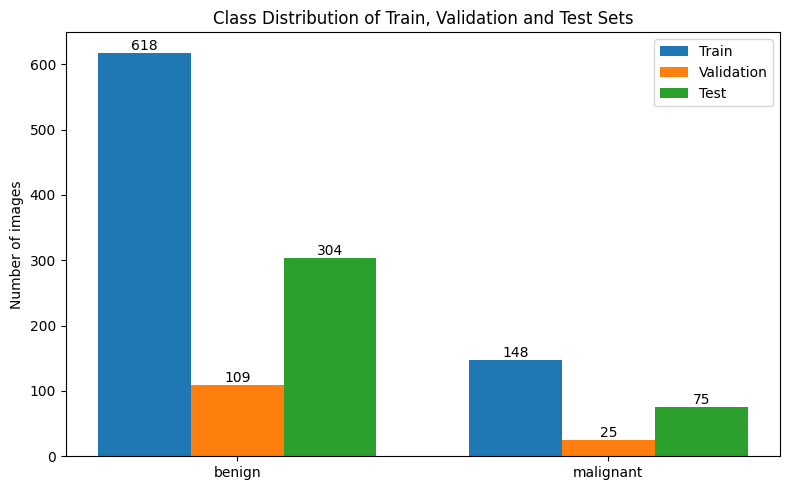

In [ ]:
labels_ = list(CFG.CLASS_TO_IDX)
counts = {
    "Train": [len(REAL_VAL_SPLIT[c]["train"]) for c in labels_],
    "Validation": [len(REAL_VAL_SPLIT[c]["val"]) for c in labels_],
    "Test": [len(os.listdir(os.path.join(CFG.LOCAL_TEST_PP, c))) for c in labels_],
}
x = np.arange(len(labels_))
plt.figure(figsize=(8, 5))
for i, (name, vals) in enumerate(counts.items()):
    bars = plt.bar(x + (i - 1) * 0.25, vals, 0.25, label=name)
    for b in bars:
        plt.text(b.get_x() + b.get_width() / 2, b.get_height(), int(b.get_height()), ha="center", va="bottom")
plt.xticks(x, labels_)
plt.ylabel("Number of images")
plt.title("Class Distribution of Train, Validation and Test Sets")
plt.legend()
plt.tight_layout()
plt.show()

## Bước 3 — StyleGAN2-ADA có điều kiện (bản chính thức NVlabs)

**3a.** Đóng gói **766 ảnh train** (618 benign + 148 malignant, không gồm val/test) thành file zip đúng định dạng
StyleGAN2-ADA: ảnh PNG 256×256 + `dataset.json` chứa nhãn lớp (benign = 0, malignant = 1).

In [ ]:
def build_stylegan_dataset_zip(cfg, split):
    labels = []
    with zipfile.ZipFile(cfg.LOCAL_GAN_DATASET, "w", compression=zipfile.ZIP_STORED) as zf:
        for label, idx in cfg.CLASS_TO_IDX.items():
            for f in split[label]["train"]:
                arcname = f"{label}/{f}"
                zf.write(os.path.join(cfg.LOCAL_TRAIN_PP, label, f), arcname=arcname)
                labels.append([arcname, idx])
        zf.writestr("dataset.json", json.dumps({"labels": labels}))
    n_per_class = {c: sum(1 for _, l in labels if l == i) for c, i in cfg.CLASS_TO_IDX.items()}
    print(f"Đã tạo {cfg.LOCAL_GAN_DATASET}: {len(labels)} ảnh {n_per_class}")


build_stylegan_dataset_zip(CFG, REAL_VAL_SPLIT)

# Kiểm tra dataset + cấu hình bằng --dry-run (không train)
sh(f"{sys.executable} train.py --outdir={CFG.LOCAL_GAN_RUNS}/dryrun --data={CFG.LOCAL_GAN_DATASET} "
   f"--gpus=1 --cond=1 --mirror={int(CFG.GAN_MIRROR)} --cfg={CFG.GAN_CFG} --batch={CFG.GAN_BATCH} "
   f"--gamma={CFG.GAN_GAMMA} --kimg=10 --metrics=none --dry-run", cwd=CFG.SG2_REPO)

Đã tạo /content/local_data/gan_dataset/isic2016_train766_cond_256.zip: 766 ảnh {'benign': 618, 'malignant': 148}
$ /usr/bin/python3 train.py --outdir=/content/local_data/gan_runs/dryrun --data=/content/local_data/gan_dataset/isic2016_train766_cond_256.zip --gpus=1 --cond=1 --mirror=1 --cfg=paper256 --batch=16 --gamma=1.0 --kimg=10 --metrics=none --dry-run

Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 50,
  "network_snapshot_ticks": 50,
  "metrics": [],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "/content/local_data/gan_dataset/isic2016_train766_cond_256.zip",
    "use_labels": true,
    "max_size": 766,
    "xflip": true,
    "resolution": 256
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 3,
    "prefetch_factor": 2
  },
  "G_kwargs": {
    "class_name": "training.networks.Generator",
    "z_dim": 512,
    "w_dim": 512,
    "mapping_kwargs": {
      "num_layers": 8
   

CompletedProcess(args='/usr/bin/python3 train.py --outdir=/content/local_data/gan_runs/dryrun --data=/content/local_data/gan_dataset/isic2016_train766_cond_256.zip --gpus=1 --cond=1 --mirror=1 --cfg=paper256 --batch=16 --gamma=1.0 --kimg=10 --metrics=none --dry-run', returncode=0, stdout='\nTraining options:\n{\n  "num_gpus": 1,\n  "image_snapshot_ticks": 50,\n  "network_snapshot_ticks": 50,\n  "metrics": [],\n  "random_seed": 0,\n  "training_set_kwargs": {\n    "class_name": "training.dataset.ImageFolderDataset",\n    "path": "/content/local_data/gan_dataset/isic2016_train766_cond_256.zip",\n    "use_labels": true,\n    "max_size": 766,\n    "xflip": true,\n    "resolution": 256\n  },\n  "data_loader_kwargs": {\n    "pin_memory": true,\n    "num_workers": 3,\n    "prefetch_factor": 2\n  },\n  "G_kwargs": {\n    "class_name": "training.networks.Generator",\n    "z_dim": 512,\n    "w_dim": 512,\n    "mapping_kwargs": {\n      "num_layers": 8\n    },\n    "synthesis_kwargs": {\n      "ch

**3b.** Công cụ đánh giá: KID tính bằng **Inception của chính StyleGAN2-ADA** (cùng detector tác giả dùng),
so ảnh malignant sinh ra (điều kiện c = malignant) với **148 ảnh malignant thật của tập train**.

In [ ]:
if CFG.SG2_REPO not in sys.path:
    sys.path.insert(0, CFG.SG2_REPO)
import dnnlib
import legacy
from metrics import metric_utils

TORCH_DEVICE = torch.device("cuda")
INCEPTION_URL = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/metrics/inception-2015-12-05.pt"


def get_inception():
    return metric_utils.get_feature_detector(INCEPTION_URL, device=TORCH_DEVICE)


@torch.no_grad()
def inception_features(images_uint8_nhwc, batch=64):
    det = get_inception()
    feats = []
    for s in range(0, len(images_uint8_nhwc), batch):
        x = torch.from_numpy(images_uint8_nhwc[s:s + batch]).permute(0, 3, 1, 2).to(TORCH_DEVICE)
        feats.append(det(x, return_features=True).cpu().numpy().astype(np.float64))
    return np.concatenate(feats, axis=0)


def load_images_uint8(paths):
    return np.stack([np.array(Image.open(p).convert("RGB")) for p in paths]).astype(np.uint8)


def kid_from_features(real, fake, num_subsets=50, max_subset_size=1000, seed=0):
    """Giống hệt metrics/kernel_inception_distance.py của StyleGAN2-ADA (có seed để lặp lại được)."""
    rng = np.random.default_rng(seed)
    n = real.shape[1]
    m = min(real.shape[0], fake.shape[0], max_subset_size)
    t = 0.0
    for _ in range(num_subsets):
        x = fake[rng.choice(fake.shape[0], m, replace=False)]
        y = real[rng.choice(real.shape[0], m, replace=False)]
        a = (x @ x.T / n + 1) ** 3 + (y @ y.T / n + 1) ** 3
        b = (x @ y.T / n + 1) ** 3
        t += (a.sum() - np.diag(a).sum()) / (m - 1) - b.sum() * 2 / m
    return float(t / num_subsets / m)


def load_G(pkl_path):
    with open(pkl_path, "rb") as f:
        return legacy.load_network_pkl(f)["G_ema"].to(TORCH_DEVICE).eval().requires_grad_(False)


@torch.no_grad()
def generate_class_images(G, n, class_idx, psi=1.0, seed=0, batch=32):
    gen = torch.Generator(device=TORCH_DEVICE).manual_seed(int(seed))
    out = []
    for s in range(0, n, batch):
        b = min(batch, n - s)
        z = torch.randn([b, G.z_dim], generator=gen, device=TORCH_DEVICE)
        c = torch.zeros([b, G.c_dim], device=TORCH_DEVICE)
        c[:, class_idx] = 1
        img = G(z, c, truncation_psi=psi, noise_mode="const")
        out.append((img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8).cpu().numpy())
    return np.concatenate(out, axis=0)


REAL_MAL_TRAIN_PATHS = [os.path.join(CFG.LOCAL_TRAIN_PP, "malignant", f) for f in REAL_VAL_SPLIT["malignant"]["train"]]
REAL_MAL_INCEPTION = inception_features(load_images_uint8(REAL_MAL_TRAIN_PATHS))
print("Inception features malignant thật (train):", REAL_MAL_INCEPTION.shape)

Inception features malignant thật (train): (148, 2048)


**3c.** Train StyleGAN2-ADA với **early stopping theo KID malignant**:

- `train.py` chính thức chạy trong tiến trình con; mỗi `GAN_KIMG_PER_SNAP` kimg tác giả lưu một snapshot.
- Notebook đánh giá KID từng snapshot. Snapshot tốt nhất được copy lên Drive (`best.pkl`), snapshot mới nhất lưu `latest.pkl` để resume.
- Sau `GAN_MIN_KIMG`, nếu KID không giảm ≥ `GAN_MIN_REL_DELTA` trong `GAN_PATIENCE` snapshot liên tiếp → **dừng train**. Generator dùng ở các bước sau là **snapshot tốt nhất**, không phải snapshot cuối.
- Nếu Colab ngắt: chạy lại cell (không đặt `fresh_start=True`) → tự resume từ `latest.pkl`, giữ nguyên lịch sử KID và bộ đếm patience.

Quy đổi: với 766 ảnh, 1 kimg ≈ 1,3 epoch; 100 kimg ≈ 130 epoch.

In [ ]:
GAN_STATE_PATH = os.path.join(CFG.DRIVE_GAN_DIR, "gan_state.json")
GAN_BEST_PKL = os.path.join(CFG.DRIVE_GAN_DIR, "best.pkl")
GAN_LATEST_PKL = os.path.join(CFG.DRIVE_GAN_DIR, "latest.pkl")


def _default_state():
    return {"cum_kimg": 0, "history": [], "best_kid": None, "best_cum_kimg": None,
            "bad_count": 0, "finished": False, "stop_reason": None}


def _load_state():
    if os.path.exists(GAN_STATE_PATH):
        with open(GAN_STATE_PATH) as f:
            return json.load(f)
    return _default_state()


def _save_state(state):
    tmp = GAN_STATE_PATH + ".tmp"
    with open(tmp, "w") as f:
        json.dump(state, f, indent=2)
    os.replace(tmp, GAN_STATE_PATH)


def _list_run_dirs(outdir):
    return sorted(d for d in glob.glob(os.path.join(outdir, "0*")) if os.path.isdir(d))


def _list_snapshots(run_dir):
    snaps = []
    for p in glob.glob(os.path.join(run_dir, "network-snapshot-*.pkl")):
        snaps.append((int(os.path.basename(p).split("-")[-1].split(".")[0]), p))
    return sorted(snaps)


def _is_file_complete(path, wait=10):
    try:
        s1 = os.path.getsize(path)
        time.sleep(wait)
        s2 = os.path.getsize(path)
    except OSError:
        return False
    return s1 > 0 and s1 == s2


def _last_tick_line(log_path):
    try:
        with open(log_path) as f:
            ticks = [l.strip() for l in f if l.startswith("tick")]
        return ticks[-1] if ticks else "(chưa có tick)"
    except OSError:
        return "(chưa có log)"


def evaluate_snapshot_kid(pkl_path):
    G = load_G(pkl_path)
    fake = generate_class_images(G, CFG.KID_N_GEN, CFG.MALIGNANT_IDX, psi=1.0, seed=CFG.KID_SEED)
    del G
    torch.cuda.empty_cache()
    return kid_from_features(REAL_MAL_INCEPTION, inception_features(fake),
                             num_subsets=CFG.KID_SUBSETS, seed=CFG.KID_SEED)


def train_stylegan2_ada_early_stopping(cfg, fresh_start=False):
    if fresh_start:
        for p in [GAN_STATE_PATH, GAN_BEST_PKL, GAN_LATEST_PKL]:
            if os.path.exists(p):
                os.remove(p)
        shutil.rmtree(cfg.LOCAL_GAN_RUNS, ignore_errors=True)
        print("fresh_start=True -> xóa trạng thái cũ, train từ đầu.")
    os.makedirs(cfg.LOCAL_GAN_RUNS, exist_ok=True)

    state = _load_state()
    if state["finished"]:
        print(f"GAN đã train xong ({state['stop_reason']}). Best KID = {state['best_kid']:.5f} "
              f"tại {state['best_cum_kimg']} kimg.")
        return GAN_BEST_PKL, state

    snap_ticks = max(1, cfg.GAN_KIMG_PER_SNAP // 4)   # 1 tick = 4 kimg (mặc định của tác giả)

    while not state["finished"]:
        offset = state["cum_kimg"]
        remaining = cfg.GAN_MAX_KIMG - offset
        if remaining < cfg.GAN_KIMG_PER_SNAP:
            state.update(finished=True, stop_reason=f"đạt GAN_MAX_KIMG={cfg.GAN_MAX_KIMG}")
            _save_state(state)
            break

        resume = None
        if offset > 0:
            if not os.path.exists(GAN_LATEST_PKL):
                raise RuntimeError("Có lịch sử train nhưng thiếu latest.pkl trên Drive -> chạy lại với fresh_start=True.")
            resume = GAN_LATEST_PKL
            print(f"Resume từ {resume} (đã train {offset} kimg)")

        cmd = [sys.executable, "train.py",
               f"--outdir={cfg.LOCAL_GAN_RUNS}", f"--data={cfg.LOCAL_GAN_DATASET}",
               "--gpus=1", "--cond=1", f"--mirror={int(cfg.GAN_MIRROR)}",
               f"--cfg={cfg.GAN_CFG}", f"--batch={cfg.GAN_BATCH}", f"--gamma={cfg.GAN_GAMMA}",
               f"--kimg={remaining}", f"--snap={snap_ticks}", "--metrics=none",
               "--aug=ada", f"--target={cfg.GAN_AUG_TARGET}", f"--seed={SEED}", "--workers=2"]
        if resume:
            cmd.append(f"--resume={resume}")
        print("Lệnh:", " ".join(cmd))

        existing_runs = set(_list_run_dirs(cfg.LOCAL_GAN_RUNS))
        log_path = os.path.join(cfg.LOCAL_GAN_RUNS, f"train_log_from_{offset}kimg.txt")
        log_f = open(log_path, "w")
        proc = subprocess.Popen(cmd, cwd=cfg.SG2_REPO, stdout=log_f, stderr=subprocess.STDOUT)

        run_dir = None
        evaluated = set()
        early_stopped = False

        def process_new_snapshots():
            nonlocal early_stopped
            if run_dir is None:
                return
            for kimg, pkl in _list_snapshots(run_dir):
                if pkl in evaluated:
                    continue
                if kimg == 0:                      # snapshot khởi tạo / mạng vừa resume -> bỏ qua
                    evaluated.add(pkl)
                    continue
                if not _is_file_complete(pkl):
                    return
                evaluated.add(pkl)
                cum = offset + kimg
                kid = evaluate_snapshot_kid(pkl)
                improved = state["best_kid"] is None or kid < state["best_kid"] * (1 - cfg.GAN_MIN_REL_DELTA)
                if improved:
                    shutil.copy2(pkl, GAN_BEST_PKL)
                    state.update(best_kid=kid, best_cum_kimg=cum, bad_count=0)
                elif cum >= cfg.GAN_MIN_KIMG:
                    state["bad_count"] += 1
                shutil.copy2(pkl, GAN_LATEST_PKL)
                state["cum_kimg"] = cum
                state["history"].append({"cum_kimg": cum, "kid": kid, "improved": bool(improved)})
                _save_state(state)
                os.remove(pkl)                      # đã lưu best/latest trên Drive, xóa bản cục bộ cho nhẹ đĩa
                print(f"[snapshot] {cum:5d} kimg | KID malignant = {kid * 1e3:7.3f}e-3 | "
                      f"best = {state['best_kid'] * 1e3:7.3f}e-3 @ {state['best_cum_kimg']} kimg | "
                      f"patience {state['bad_count']}/{cfg.GAN_PATIENCE}{'  <-- tốt nhất' if improved else ''}")
                print("           ", _last_tick_line(log_path))
                if state["bad_count"] >= cfg.GAN_PATIENCE:
                    early_stopped = True
                    state.update(finished=True,
                                 stop_reason=f"early stopping tại {cum} kimg (best {state['best_cum_kimg']} kimg)")
                    _save_state(state)
                    return

        ret = None
        last_print = time.time()
        try:
            while True:
                ret = proc.poll()
                if run_dir is None:
                    new_runs = [d for d in _list_run_dirs(cfg.LOCAL_GAN_RUNS) if d not in existing_runs]
                    if new_runs:
                        run_dir = new_runs[0]
                        print("Thư mục run:", run_dir)
                process_new_snapshots()
                if early_stopped or ret is not None:
                    break
                if time.time() - last_print > 600:
                    print("  ...", _last_tick_line(log_path))
                    last_print = time.time()
                time.sleep(30)
        finally:
            if proc.poll() is None:
                proc.terminate()
                try:
                    proc.wait(timeout=60)
                except subprocess.TimeoutExpired:
                    proc.kill()
            log_f.close()

        if early_stopped:
            print(f"\nDỪNG SỚM: {state['stop_reason']}")
            break
        process_new_snapshots()                    # snapshot cuối (lưu khi train.py kết thúc)
        if early_stopped:
            print(f"\nDỪNG SỚM: {state['stop_reason']}")
            break
        if ret != 0:
            with open(log_path) as f:
                print("".join(f.readlines()[-60:]))
            raise RuntimeError(f"train.py lỗi (mã {ret}). Xem log: {log_path}")

    print(f"\nKết thúc. Best KID = {state['best_kid']:.5f} tại {state['best_cum_kimg']} kimg -> {GAN_BEST_PKL}")
    return GAN_BEST_PKL, state


# fresh_start=False: lần đầu tự train từ đầu (chưa có trạng thái); sau khi Colab ngắt thì tự RESUME.
# Chỉ đặt fresh_start=True khi muốn XÓA toàn bộ GAN cũ (ví dụ sau khi đổi GAN_GAMMA / GAN_CFG).
best_gan_pkl, gan_state = train_stylegan2_ada_early_stopping(CFG, fresh_start=False)

GAN đã train xong (early stopping tại 2300 kimg (best 1800 kimg)). Best KID = 0.02007 tại 1800 kimg.


**3d.** Nạp generator tốt nhất, xem đường KID và ảnh mẫu của từng lớp.

In [ ]:
for name in ["CFG", "REAL_VAL_SPLIT", "load_G", "inception_features",
             "_load_state", "GAN_BEST_PKL", "REAL_MAL_INCEPTION"]:
    print(f"{name:22s}", "OK" if name in globals() else "THIẾU")

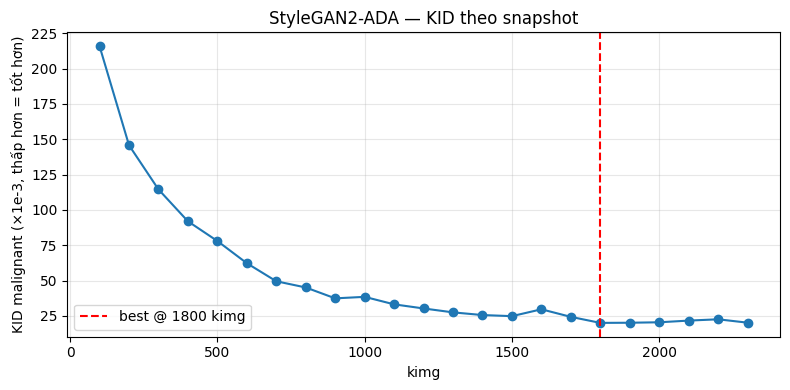

Trạng thái: early stopping tại 2300 kimg (best 1800 kimg)


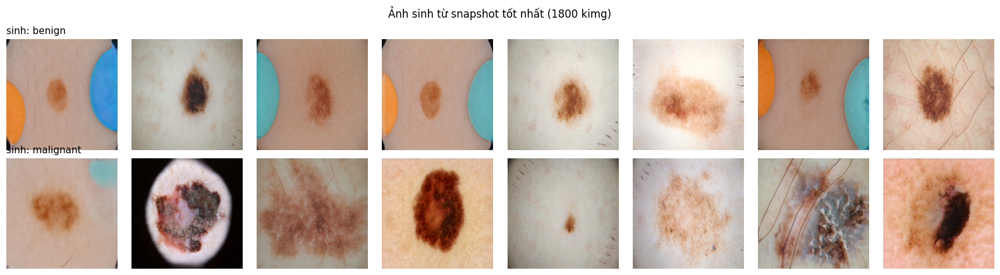

In [ ]:
gan_state = _load_state()
hist = pd.DataFrame(gan_state["history"])
if len(hist):
    plt.figure(figsize=(8, 4))
    plt.plot(hist["cum_kimg"], hist["kid"] * 1e3, marker="o")
    plt.axvline(gan_state["best_cum_kimg"], color="red", ls="--", label=f"best @ {gan_state['best_cum_kimg']} kimg")
    plt.xlabel("kimg")
    plt.ylabel("KID malignant (×1e-3, thấp hơn = tốt hơn)")
    plt.title("StyleGAN2-ADA — KID theo snapshot")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
print("Trạng thái:", gan_state["stop_reason"])

G_best = load_G(GAN_BEST_PKL)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for row, (label, idx) in enumerate(CFG.CLASS_TO_IDX.items()):
    imgs = generate_class_images(G_best, 8, idx, psi=CFG.TRUNC_PSI, seed=1)
    for col in range(8):
        axes[row, col].imshow(imgs[col])
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"sinh: {label}", loc="left", fontsize=11)
plt.suptitle(f"Ảnh sinh từ snapshot tốt nhất ({gan_state['best_cum_kimg']} kimg)")
plt.tight_layout()
plt.show()

## Bước 4 — Sinh ảnh ứng viên cho **cả hai lớp**

Với mỗi lớp, sinh `k × n_synth` ảnh có điều kiện theo nhãn của lớp đó (pool lồng nhau giữa các giá trị k để
so sánh công bằng). Pool được nén lên Drive; phiên sau **giải nén lại đúng pool đó** thay vì sinh lại,
để mọi lần chạy classifier dùng cùng một bộ ảnh.

In [ ]:
GEN_SCRIPT = "/content/gen_pool_subprocess.py"
GEN_SOURCE = """
import sys, os, glob
import torch
from PIL import Image

repo, pkl, out_dir, class_idx, n_images, psi, seed, batch = sys.argv[1:9]
class_idx, n_images, seed, batch = int(class_idx), int(n_images), int(seed), int(batch)
psi = float(psi)
sys.path.insert(0, repo)
import legacy

device = torch.device('cuda')
with open(pkl, 'rb') as fh:
    G = legacy.load_network_pkl(fh)['G_ema'].to(device).eval().requires_grad_(False)
os.makedirs(out_dir, exist_ok=True)
gen = torch.Generator(device=device).manual_seed(seed)
done = 0
with torch.no_grad():
    while done < n_images:
        b = min(batch, n_images - done)
        z = torch.randn([b, G.z_dim], generator=gen, device=device)
        c = torch.zeros([b, G.c_dim], device=device)
        c[:, class_idx] = 1
        img = G(z, c, truncation_psi=psi, noise_mode='const')
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8).cpu().numpy()
        for j in range(b):
            Image.fromarray(img[j]).save(os.path.join(out_dir, 'synth_%05d.png' % (done + j)), format='PNG')
        done += b
        if done % 200 == 0 or done == n_images:
            print('%d/%d' % (done, n_images), flush=True)
print('DONE %d' % len(glob.glob(os.path.join(out_dir, '*.png'))), flush=True)
"""
with open(GEN_SCRIPT, "w") as f:
    f.write(GEN_SOURCE)


def generate_pool(cfg, n_images, class_idx, pool_name, seed, batch=16):
    out_dir = os.path.join(cfg.LOCAL_CANDIDATES, pool_name)
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir, exist_ok=True)
    cmd = [sys.executable, GEN_SCRIPT, cfg.SG2_REPO, GAN_BEST_PKL, out_dir,
           str(class_idx), str(n_images), str(cfg.TRUNC_PSI), str(seed), str(batch)]
    print("Sinh ảnh (tiến trình con):", " ".join(cmd))
    proc = subprocess.Popen(cmd, cwd=cfg.SG2_REPO, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    tail = []
    for line in proc.stdout:
        line = line.rstrip()
        tail = (tail + [line])[-25:]
        if "/" in line or line.startswith("DONE"):
            print("   ", line)
    proc.wait()
    if proc.returncode != 0:
        print("\n".join(tail))
        raise RuntimeError(f"Tiến trình sinh ảnh lỗi (mã {proc.returncode})")
    return sorted(glob.glob(os.path.join(out_dir, "*.png")))


def get_or_restore_pool(cfg, n_images, class_idx, pool_name, seed, tag):
    zip_path = os.path.join(cfg.DRIVE_DATA_DIR, f"{pool_name}_{tag}.zip")
    pool_dir = os.path.join(cfg.LOCAL_CANDIDATES, pool_name)
    if os.path.exists(zip_path):
        shutil.rmtree(pool_dir, ignore_errors=True)
        shutil.unpack_archive(zip_path, pool_dir)
        paths = sorted(glob.glob(os.path.join(pool_dir, "*.png")))
        print(f"Khôi phục {len(paths)} ảnh từ {zip_path}")
    else:
        paths = generate_pool(cfg, n_images, class_idx, pool_name, seed)
        shutil.make_archive(zip_path[:-4], "zip", pool_dir)
        print(f"Đã sinh {len(paths)} ảnh và lưu {zip_path}")
    return paths


TAG = f"from{gan_state['best_cum_kimg']}kimg_n{POOL_SIZE}"
CANDIDATE_POOL = get_or_restore_pool(CFG, POOL_SIZE, CFG.CLASS_TO_IDX[MINORITY],
                                     f"pool_{MINORITY}", CFG.GEN_SEED, TAG)
print(f"Candidate pool: {len(CANDIDATE_POOL)} ảnh ({MINORITY}) | cần chọn {N_SELECT}")
gc.collect()
torch.cuda.empty_cache()
POOLS = {MINORITY: CANDIDATE_POOL}   # các cell miền tần số làm việc trên dict này

Sinh ảnh (tiến trình con): /usr/bin/python3 /content/gen_pool_subprocess.py /content/stylegan2-ada-pytorch /content/drive/MyDrive/Colab Notebooks/ColabData/ISBI2016_ISIC_Part3/checkpoints_v5/stylegan2ada/best.pkl /content/local_data/candidates_v7/pool_malignant 1 1880 1.0 777 16
    400/1880
    800/1880
    1200/1880
    1600/1880
    1880/1880
    DONE 1880
Đã sinh 1880 ảnh và lưu /content/drive/MyDrive/Colab Notebooks/ColabData/ISBI2016_ISIC_Part3/checkpoints_v7/data/pool_malignant_from1800kimg_n1880.zip
Candidate pool: 1880 ảnh (malignant) | cần chọn 470


## Bước 4b — Phân tích fingerprint miền tần số (Frank et al., ICML 2020 — **dùng code gốc**)

Clone repo chính thức `RUB-SysSec/GANDCTAnalysis` (MIT) và gọi trực tiếp các hàm của tác giả:
`src.image_np.load_image`, `src.image_np.dct2`, `src.math.log_scale`, `src.math.welford`,
`src.models.build_simple_cnn`, `src.models.build_multinomial_regression`. Chuỗi xử lý giữ đúng thứ tự trong
`prepare_dataset.py` của họ: `load_image → dct2 → log_scale → normalize`.

Vai trò: **phân tích và phát hiện** fingerprint tần số của ảnh sinh, làm số đo cơ sở cho Bước 4b2 và 4c.
Notebook đo cho **từng lớp** (ảnh thật của lớp đó với ảnh sinh của lớp đó).

Chênh lệch kênh màu — malignant: thật = 23.0026 | sinh = 22.5578


DCT thật [goc_malignant]:   0%|          | 0/148 [00:00<?, ?it/s]

DCT sinh [goc_malignant]:   0%|          | 0/400 [00:00<?, ?it/s]

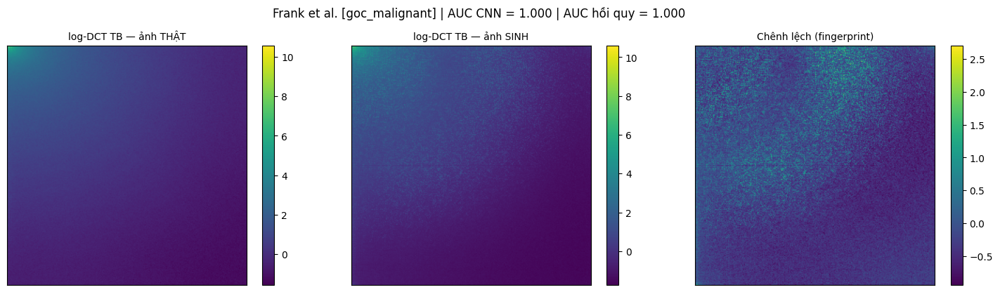

  [goc/malignant] auc_frank_cnn=1.0000 | auc_frank_regression=1.0000 | auc_power_profile=0.9984


In [ ]:
FRANK_REPO = "/content/GANDCTAnalysis"
if not os.path.isdir(FRANK_REPO):
    sh(f"git clone -q https://github.com/RUB-SysSec/GANDCTAnalysis.git {FRANK_REPO}")
if FRANK_REPO not in sys.path:
    sys.path.insert(0, FRANK_REPO)

# [PATCH] Keras 3 bắt buộc truyền pool_size cho AveragePooling2D (Keras 2 mặc định (2,2))
_models_py = os.path.join(FRANK_REPO, "src", "models.py")
_src = open(_models_py).read()
if "layers.AveragePooling2D()" in _src:
    open(_models_py, "w").write(_src.replace("layers.AveragePooling2D()", "layers.AveragePooling2D(pool_size=(2, 2))"))
    print("[patch] GANDCTAnalysis/src/models.py: AveragePooling2D(pool_size=(2, 2))")

# --- Code gốc của Frank et al. (ICML 2020) ---
from src.image_np import dct2 as frank_dct2, load_image as frank_load_image
from src.math import log_scale as frank_log_scale, welford as frank_welford
from src.models import build_simple_cnn as frank_build_simple_cnn
from src.models import build_multinomial_regression as frank_build_regression

from sklearn.metrics import roc_auc_score

FREQ_FIG_DIR = os.path.join(CFG.DRIVE_RESULTS_DIR, "frequency_analysis")
os.makedirs(FREQ_FIG_DIR, exist_ok=True)

REAL_TRAIN_PATHS = {c: [os.path.join(CFG.LOCAL_TRAIN_PP, c, f) for f in REAL_VAL_SPLIT[c]["train"]]
                    for c in CFG.CLASS_TO_IDX}


def channel_gap(path):
    """Mức lệch giữa các kênh R,G,B. Ảnh xám thuần cho đúng 0.0."""
    a = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64)
    return float(np.abs(np.diff(a, axis=2)).mean())


def radial_power_profile(magnitude):
    """Algorithm 1 (Dong et al.): cộng biên độ theo bán kính, chuẩn hoá theo thành phần DC."""
    M = magnitude.shape[0]
    yy, xx = np.mgrid[0:M, 0:M]
    idx = np.floor(np.sqrt((yy - 0.5 * M) ** 2 + (xx - 0.5 * M) ** 2)).astype(int)
    prof = np.bincount(idx.ravel(), weights=magnitude.ravel(), minlength=int(np.floor(np.sqrt(2) * M)))
    return prof / (prof[0] + 1e-12)


def frank_dct_log(path):
    return frank_log_scale(frank_dct2(frank_load_image(path, grayscale=True))).astype(np.float32)


def frank_frequency_detector(real_paths, fake_paths, tag, n_max=400, epochs=15, seed=SEED):
    """Bộ phát hiện miền tần số của Frank et al.: log-DCT + chuẩn hoá welford + CNN nông / hồi quy."""
    rng = np.random.default_rng(seed)
    rp = list(rng.choice(real_paths, min(n_max, len(real_paths)), replace=False))
    fp = list(rng.choice(fake_paths, min(n_max, len(fake_paths)), replace=False))
    X_real = np.stack([frank_dct_log(p) for p in tqdm(rp, desc=f"DCT thật [{tag}]")])
    X_fake = np.stack([frank_dct_log(p) for p in tqdm(fp, desc=f"DCT sinh [{tag}]")])
    X = np.concatenate([X_real, X_fake])
    y = np.r_[np.zeros(len(X_real)), np.ones(len(X_fake))].astype(np.float32)

    idx = rng.permutation(len(X))
    tr, te = idx[:int(0.8 * len(X))], idx[int(0.8 * len(X)):]
    mean, var = frank_welford(X[tr])
    Xn = ((X - mean) / (np.sqrt(var) + 1e-12))[..., None].astype(np.float32)

    aucs = {}
    for name, builder in [("cnn", lambda: frank_build_simple_cnn(Xn.shape[1:], 1)),
                          ("regression", lambda: frank_build_regression(Xn.shape[1:], 1))]:
        tf.keras.utils.set_random_seed(seed)
        model = builder()
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        model.fit(Xn[tr], y[tr], validation_data=(Xn[te], y[te]), epochs=epochs, batch_size=32, verbose=0)
        aucs[name] = float(roc_auc_score(y[te], model.predict(Xn[te], verbose=0).ravel()))
        del model
        tf.keras.backend.clear_session()

    mean_real, mean_fake = X_real.mean(axis=0), X_fake.mean(axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, (m, t) in zip(axes, [(mean_real, "log-DCT TB — ảnh THẬT"), (mean_fake, "log-DCT TB — ảnh SINH"),
                                 (mean_fake - mean_real, "Chênh lệch (fingerprint)")]):
        im = ax.imshow(m, cmap="viridis")
        ax.set_title(t, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"Frank et al. [{tag}] | AUC CNN = {aucs['cnn']:.3f} | AUC hồi quy = {aucs['regression']:.3f}")
    fig.tight_layout()
    fig.savefig(os.path.join(FREQ_FIG_DIR, f"frank_dct_{tag}.png"), dpi=120, bbox_inches="tight")
    plt.show()
    return aucs


def power_profile_auc(real_paths, fake_paths, n_max=400, seed=SEED):
    """Bộ phát hiện dựa trên profile công suất — thứ mà PDC của Dong et al. nhắm tới."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    rng = np.random.default_rng(seed)
    rp = list(rng.choice(real_paths, min(n_max, len(real_paths)), replace=False))
    fp = list(rng.choice(fake_paths, min(n_max, len(fake_paths)), replace=False))
    prof = lambda ps: np.stack([radial_power_profile(np.abs(np.fft.fftshift(
        np.fft.fft2(np.asarray(Image.open(p).convert("L"), dtype=np.float64))))) for p in ps])
    X = np.concatenate([prof(rp), prof(fp)])
    y = np.r_[np.zeros(len(rp)), np.ones(len(fp))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    return float(roc_auc_score(y, p))


def fingerprint_report(stage, pools, n_max=400):
    rows = []
    for c in pools:
        aucs = frank_frequency_detector(REAL_TRAIN_PATHS[c], pools[c], f"{stage}_{c}", n_max=n_max)
        rows.append({"giai_doan": stage, "lop": c,
                     "auc_frank_cnn": aucs["cnn"], "auc_frank_regression": aucs["regression"],
                     "auc_power_profile": power_profile_auc(REAL_TRAIN_PATHS[c], pools[c], n_max=n_max),
                     "chenh_lech_kenh_sinh": float(np.mean([channel_gap(p) for p in pools[c][:100]]))})
        print(f"  [{stage}/{c}] " + " | ".join(f"{k}={v:.4f}" for k, v in rows[-1].items() if k.startswith("auc")))
    return rows


for c in POOLS:
    print(f"Chênh lệch kênh màu — {c}: thật = {np.mean([channel_gap(p) for p in REAL_TRAIN_PATHS[c][:100]]):.4f}"
          f" | sinh = {np.mean([channel_gap(p) for p in POOLS[c][:100]]):.4f}")
freq_reports = fingerprint_report("goc", POOLS)

## Bước 4b2 — Chuẩn hoá đặc tính kỹ thuật của ảnh sinh

Trước khi kết luận AUC cao là do fingerprint của generator, phải loại trừ hai khác biệt **do quy trình xử lý**:

1. **Kênh màu.** Nếu ảnh thật là ảnh xám thuần (chênh lệch kênh = 0), ảnh GAN 3 kênh sẽ bị phát hiện tuyệt đối,
   và hiệu chỉnh phổ **không xử lý được** vì nó chạy độc lập trên từng kênh. Với ảnh dermoscopy màu của ISIC,
   chênh lệch kênh của ảnh thật khác 0 nên bước này **tự động bỏ qua** (`HARMONIZE_SYNTH_CHANNELS = "auto"`).
2. **Chuỗi resize.** Ảnh thật đi qua crop + resize bilinear về 256, để lại dấu vết nội suy; ảnh GAN sinh thẳng ở 256.
   Bật `MATCH_RESIZE_CHAIN = True` để cho ảnh sinh đi qua cùng chuỗi nội suy.

In [ ]:
def harmonize_pool(paths, pool_name, cfg, tag):
    zip_path = os.path.join(cfg.DRIVE_DATA_DIR, f"{pool_name}_harmonized_{tag}.zip")
    out_dir = os.path.join(cfg.LOCAL_CANDIDATES, f"{pool_name}_harmonized")
    if os.path.exists(zip_path):
        shutil.rmtree(out_dir, ignore_errors=True)
        shutil.unpack_archive(zip_path, out_dir)
        new_paths = sorted(glob.glob(os.path.join(out_dir, "*.png")))
        print(f"Khôi phục {len(new_paths)} ảnh đã chuẩn hoá từ {zip_path}")
        return new_paths
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)
    new_paths = []
    for p in tqdm(paths, desc=f"Chuẩn hoá {pool_name}"):
        img = Image.open(p).convert("RGB")
        if cfg.MATCH_RESIZE_CHAIN and RESIZE_REF_SIDE:
            img = img.resize((RESIZE_REF_SIDE, RESIZE_REF_SIDE), _BILINEAR).resize(
                (cfg.IMG_SIZE, cfg.IMG_SIZE), _BILINEAR)
        if cfg.HARMONIZE_SYNTH_CHANNELS:
            g = np.asarray(img.convert("L"))
            img = Image.fromarray(np.stack([g] * 3, axis=-1))
        q = os.path.join(out_dir, os.path.basename(p))
        img.save(q, format="PNG")
        new_paths.append(q)
    shutil.make_archive(zip_path[:-4], "zip", out_dir)
    print("Đã lưu", zip_path)
    return new_paths


real_gap = float(np.mean([channel_gap(p) for p in REAL_TRAIN_PATHS["malignant"][:100]]))
if CFG.HARMONIZE_SYNTH_CHANNELS == "auto":
    CFG.HARMONIZE_SYNTH_CHANNELS = real_gap < 1e-6
    print(f"Chênh lệch kênh màu của ảnh thật = {real_gap:.6f} -> "
          f"HARMONIZE_SYNTH_CHANNELS = {CFG.HARMONIZE_SYNTH_CHANNELS}")

RESIZE_REF_SIDE = None
if CFG.MATCH_RESIZE_CHAIN:
    raw_files = sorted(glob.glob(os.path.join(CFG.LOCAL_TRAIN_RAW, "malignant", "*")))[:200]
    RESIZE_REF_SIDE = int(np.median([min(Image.open(p).size) for p in raw_files]))
    print(f"Trung vị cạnh ngắn của ảnh gốc = {RESIZE_REF_SIDE}")

if CFG.HARMONIZE_SYNTH_CHANNELS or CFG.MATCH_RESIZE_CHAIN:
    POOLS = {c: harmonize_pool(POOLS[c], f"pool_{c}", CFG, TAG) for c in POOLS}
    CANDIDATE_POOL = POOLS[MINORITY]
    freq_reports += fingerprint_report("sau_chuan_hoa", POOLS)
    print(pd.DataFrame(freq_reports).round(4).to_string(index=False))
else:
    print("Ảnh thật không phải ảnh xám thuần và MATCH_RESIZE_CHAIN = False -> bỏ qua bước chuẩn hoá.")

Chênh lệch kênh màu của ảnh thật = 23.002606 -> HARMONIZE_SYNTH_CHANNELS = False
Ảnh thật không phải ảnh xám thuần và MATCH_RESIZE_CHAIN = False -> bỏ qua bước chuẩn hoá.


## Bước 4c — Spectral artifact mitigation (Dong et al., CVPR 2022)

**Thành phần tham khảo từ nghiên cứu trước**, dùng để **kiểm soát shortcut tổng hợp** trước bước lọc, không phải
đóng góp của nghiên cứu này và không gọi là "khử nhiễu ảnh".

Notebook tải gói mã nguồn của tác giả (`comp.polyu.edu.hk/~csajaykr/CVPR2022.zip`), in cây thư mục và readme.
Nếu gói có Python, thư mục được thêm vào `sys.path` để gọi trực tiếp; nếu là MATLAB, notebook dùng bản cài đặt
theo đúng **Algorithm 1–3** trong bài (SDN và PDC, giữ nguyên phổ pha).

Giấy phép của tác giả: bảo lưu mọi quyền, cấm dùng và phân phối vì mục đích thương mại.

Sau mitigation, notebook in **SSIM trước/sau** (bài báo báo cáo ~0,93–0,98), hiện lưới ảnh trước/sau, và
**đo lại fingerprint** để so ba mốc: gốc → sau chuẩn hoá → sau mitigation.

In [ ]:
DONG_URL = "http://www.comp.polyu.edu.hk/~csajaykr/CVPR2022.zip"
DONG_DIR = "/content/dong_cvpr2022"
DONG_PY_AVAILABLE = False


def fetch_dong_code():
    global DONG_PY_AVAILABLE
    os.makedirs(DONG_DIR, exist_ok=True)
    zip_path = os.path.join(DONG_DIR, "CVPR2022.zip")
    try:
        if not os.path.exists(zip_path):
            import urllib.request
            print("Đang tải mã nguồn Dong et al. ...")
            urllib.request.urlretrieve(DONG_URL, zip_path)
        if not glob.glob(os.path.join(DONG_DIR, "*", "")):
            shutil.unpack_archive(zip_path, DONG_DIR)
    except Exception as e:
        print("Không tải/giải nén được gói mã nguồn:", repr(e), "-> dùng bản theo Algorithm 1-3.")
        return False
    files = [p for p in glob.glob(os.path.join(DONG_DIR, "**", "*"), recursive=True) if os.path.isfile(p)]
    print(f"Đã giải nén {len(files)} file vào {DONG_DIR}:")
    for p in sorted(files)[:40]:
        print("   ", os.path.relpath(p, DONG_DIR))
    for p in files:
        if os.path.basename(p).lower().startswith("readme"):
            print("\n--- README (2000 ký tự đầu) ---")
            print(open(p, errors="ignore").read()[:2000])
            break
    py_files = [p for p in files if p.endswith(".py")]
    print(f"\nPython: {len(py_files)} file | MATLAB: {sum(p.endswith('.m') for p in files)} file")
    if py_files:
        for d in {os.path.dirname(p) for p in py_files} | {DONG_DIR}:
            if d not in sys.path:
                sys.path.insert(0, d)
        DONG_PY_AVAILABLE = True
    return DONG_PY_AVAILABLE


# ---- Bản cài đặt theo Algorithm 1-3 của bài báo ----
def _fft_channels(path):
    a = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64)
    F = np.fft.fftshift(np.fft.fft2(a, axes=(0, 1)), axes=(0, 1))
    return np.abs(F), np.angle(F)


def mean_magnitude(paths, desc):
    acc = None
    for p in tqdm(paths, desc=desc):
        mag, _ = _fft_channels(p)
        acc = mag if acc is None else acc + mag
    return acc / len(paths)


def build_power_dictionary(paths, desc="Từ điển công suất (Algorithm 1)"):
    dic = []
    for p in tqdm(paths, desc=desc):
        mag, _ = _fft_channels(p)
        dic.append(np.stack([radial_power_profile(mag[..., c]) for c in range(mag.shape[-1])]))
    return np.stack(dic)


def _radial_index(M):
    yy, xx = np.mgrid[0:M, 0:M]
    return np.floor(np.sqrt((yy - 0.5 * M) ** 2 + (xx - 0.5 * M) ** 2)).astype(int)


def mitigate_image(path, delta, power_dict, mode="sdn+pdc"):
    """SDN (Algorithm 2) và/hoặc PDC (Algorithm 3); phổ pha giữ nguyên."""
    mag, phase = _fft_channels(path)
    if "sdn" in mode:
        mag = np.clip(mag - delta, 0.0, None)
    if "pdc" in mode:
        idx = _radial_index(mag.shape[0])
        K = power_dict.shape[-1]
        for c in range(mag.shape[-1]):
            Ps = radial_power_profile(mag[..., c])
            q = max(4, K // 4)
            r = int(np.argmin(((Ps[:q] - power_dict[:, c, :q]) ** 2).sum(axis=1)))
            mag[..., c] = mag[..., c] * (power_dict[r, c] / (Ps + 1e-12))[idx]
    out = np.fft.ifft2(np.fft.ifftshift(mag * np.exp(1j * phase), axes=(0, 1)), axes=(0, 1)).real
    return np.clip(out, 0, 255).round().astype(np.uint8)


def mitigate_pool(paths, real_paths, pool_name, cfg, tag):
    zip_path = os.path.join(cfg.DRIVE_DATA_DIR, f"{pool_name}_mitigated_{cfg.MITIGATION_MODE}_{tag}.zip")
    out_dir = os.path.join(cfg.LOCAL_CANDIDATES, f"{pool_name}_mitigated")
    if os.path.exists(zip_path):
        shutil.rmtree(out_dir, ignore_errors=True)
        shutil.unpack_archive(zip_path, out_dir)
        new_paths = sorted(glob.glob(os.path.join(out_dir, "*.png")))
        print(f"Khôi phục {len(new_paths)} ảnh đã mitigation từ {zip_path}")
        return new_paths, None
    delta = mean_magnitude(paths, "Phổ TB ảnh sinh") - mean_magnitude(real_paths, "Phổ TB ảnh thật")
    power_dict = build_power_dictionary(real_paths)
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)
    ssim_scores, new_paths = [], []
    for p in tqdm(paths, desc=f"Mitigation {pool_name} ({cfg.MITIGATION_MODE})"):
        fixed = mitigate_image(p, delta, power_dict, cfg.MITIGATION_MODE)
        ssim_scores.append(structural_similarity(np.asarray(Image.open(p).convert("RGB")), fixed,
                                                 channel_axis=2, data_range=255))
        q = os.path.join(out_dir, os.path.basename(p))
        Image.fromarray(fixed).save(q, format="PNG")
        new_paths.append(q)
    shutil.make_archive(zip_path[:-4], "zip", out_dir)
    ssim_scores = np.array(ssim_scores)
    print(f"SSIM trước/sau: trung bình {ssim_scores.mean():.4f} "
          f"(min {ssim_scores.min():.4f}, max {ssim_scores.max():.4f}) — bài báo ~0.93–0.98")
    return new_paths, ssim_scores


def show_before_after(before_paths, after_paths, title, n=6):
    fig, axes = plt.subplots(2, n, figsize=(n * 2.0, 4.4))
    for c in range(n):
        axes[0, c].imshow(Image.open(before_paths[c]))
        axes[1, c].imshow(Image.open(after_paths[c]))
        for r in range(2):
            axes[r, c].axis("off")
    axes[0, 0].set_title("trước mitigation", loc="left", fontsize=10)
    axes[1, 0].set_title("sau mitigation", loc="left", fontsize=10)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(os.path.join(FREQ_FIG_DIR, f"before_after_{title}.png"), dpi=120, bbox_inches="tight")
    plt.show()


if CFG.APPLY_SPECTRAL_MITIGATION:
    from skimage.metrics import structural_similarity

    fetch_dong_code()
    print(f"\nChế độ mitigation: {CFG.MITIGATION_MODE} | nguồn: "
          f"{'code gốc trong sys.path' if DONG_PY_AVAILABLE else 'Algorithm 1-3 theo bài báo'}")
    POOLS_RAW = {c: list(POOLS[c]) for c in POOLS}
    for c in POOLS:
        POOLS[c], _ = mitigate_pool(POOLS_RAW[c], REAL_TRAIN_PATHS[c], f"pool_{c}", CFG, TAG)
        show_before_after(POOLS_RAW[c], POOLS[c], c)
    CANDIDATE_POOL = POOLS[MINORITY]
    freq_reports += fingerprint_report("sau_mitigation", POOLS)
    freq_df = pd.DataFrame(freq_reports)
    freq_df.to_csv(os.path.join(CFG.DRIVE_RESULTS_DIR, "frequency_fingerprint_auc.csv"), index=False)
    print("\n=== Fingerprint miền tần số qua các giai đoạn ===")
    print(freq_df.round(4).to_string(index=False))
else:
    print("APPLY_SPECTRAL_MITIGATION = False -> dùng ảnh sinh gốc.")

APPLY_SPECTRAL_MITIGATION = False -> dùng ảnh sinh gốc.


## Bước 5 — $E_v$: bộ mã hoá đặc trưng thị giác (ImageNet, đóng băng)

EfficientNet-B0 pretrained ImageNet, bỏ đầu phân loại, lấy vector sau global average pooling rồi **chuẩn hoá L2**.
Độ tương đồng dùng trung bình cosine với **TOP-K** ảnh thật gần nhất (K = `CFG.SIM_TOPK`) thay vì `max`,
vì `max` chỉ phụ thuộc một ảnh thật nên rất nhạy với ngoại lai.

```
S_v⁺(x) = (1/K) Σ cos(z_x^v, z_i^v)   với K ảnh THẬT gần nhất thuộc lớp thiểu số
S_v⁻(x) = (1/K) Σ cos(z_x^v, z_j^v)   với K ảnh THẬT gần nhất thuộc lớp đa số
M_v(x)  = S_v⁺(x) − λ_v · S_v⁻(x)
```

In [ ]:
_E_V = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", pooling="avg",
    input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3))
_E_V.trainable = False


def _image_dataset(image_paths, preprocess_fn, batch_size=32):
    def _load(path):
        img = tf.io.decode_png(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, [CFG.CLF_SIZE, CFG.CLF_SIZE])
        return preprocess_fn(img)
    return (tf.data.Dataset.from_tensor_slices(list(image_paths))
            .map(_load, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE))


def l2_normalize(emb):
    return emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)


def embed_visual(image_paths, batch_size=32):
    """z_v: đặc trưng thị giác từ E_v (ImageNet), chuẩn hoá L2."""
    ds = _image_dataset(image_paths, tf.keras.applications.efficientnet.preprocess_input, batch_size)
    return l2_normalize(_E_V.predict(ds, verbose=0))


def cosine_similarity_matrix(A, B):
    return l2_normalize(A) @ l2_normalize(B).T


def topk_similarity(candidate_emb, reference_emb, topk=None):
    topk = CFG.SIM_TOPK if topk is None else topk
    sim = cosine_similarity_matrix(candidate_emb, reference_emb)
    k = int(min(topk, sim.shape[1]))
    return np.sort(sim, axis=1)[:, -k:].mean(axis=1)


def margin_score(candidate_emb, pos_emb, neg_emb, lam):
    """M(x) = S⁺(x) − lam · S⁻(x)."""
    s_pos = topk_similarity(candidate_emb, pos_emb)
    s_neg = topk_similarity(candidate_emb, neg_emb)
    return s_pos - lam * s_neg, s_pos, s_neg


Z_V_REAL = {c: embed_visual(REAL_TRAIN_PATHS[c]) for c in CFG.CLASS_TO_IDX}
Z_V_POOL = embed_visual(CANDIDATE_POOL)
print("z_v — thật:", {c: Z_V_REAL[c].shape for c in Z_V_REAL}, "| pool:", Z_V_POOL.shape)

z_v — thật: {'benign': (618, 1280), 'malignant': (148, 1280)} | pool: (1880, 1280)


## Bước 5b — $E_d$: bộ mã hoá nhận biết bệnh (huấn luyện có giám sát)

$E_d$ được huấn luyện bằng Cross-Entropy trên **nhãn thật** của tập train (không thấy val, test, hay ảnh sinh).
Sau khi train, bỏ đầu phân loại và giữ tầng áp chót làm bộ trích đặc trưng $z_d$, chuẩn hoá L2.

```
S_d⁺(x) = (1/K) Σ cos(z_x^d, z_i^d)   K ảnh THẬT gần nhất thuộc lớp thiểu số
S_d⁻(x) = (1/K) Σ cos(z_x^d, z_j^d)   K ảnh THẬT gần nhất thuộc lớp đa số
M_d(x)  = S_d⁺(x) − λ_d · S_d⁻(x)
```

**Vì sao không dùng lại M0.** M0 là mốc đối chứng của thí nghiệm. Nếu dùng chính M0 để chọn ảnh rồi lại so sánh
với M0, ảnh được chọn sẽ chỉ củng cố ranh giới mà M0 đã có. $E_d$ vì vậy là mô hình riêng, với kiến trúc
(`CFG.E_D_MODEL`) và seed (`CFG.E_D_SEED`) riêng.

Cell cũng in **AUC probe** của hai không gian trên **tập val** (ảnh mà cả hai bộ mã hoá đều không dùng để chọn
ảnh sinh) — đây là số đo khách quan để so $E_d$ với $E_v$.

In [ ]:
def build_real_only_dirs(cfg, split):
    """Thư mục ảnh THẬT (train/val) để huấn luyện E_d."""
    root = cfg.LOCAL_REAL_ONLY
    for s in ["train", "val"]:
        for c in cfg.CLASS_TO_IDX:
            os.makedirs(os.path.join(root, s, c), exist_ok=True)
    for c in cfg.CLASS_TO_IDX:
        for s in ["train", "val"]:
            for f in split[c][s]:
                dst = os.path.join(root, s, c, f)
                if not os.path.exists(dst):
                    shutil.copy2(os.path.join(cfg.LOCAL_TRAIN_PP, c, f), dst)
    return root


def train_disease_encoder(cfg, seed=None):
    """Huấn luyện E_d (Cross-Entropy trên ảnh thật) rồi trả về (feature_extractor, preprocess)."""
    seed = seed or cfg.E_D_SEED
    ckpt = os.path.join(cfg.DRIVE_CLF_DIR, f"Ed_{cfg.E_D_MODEL}_s{seed}.weights.h5")
    model, base, preprocess = MODEL_BUILDERS[cfg.E_D_MODEL]()

    if os.path.exists(ckpt):
        model.load_weights(ckpt)
        print(f"Đã nạp E_d từ {os.path.basename(ckpt)}")
    else:
        print(f"Chưa có {os.path.basename(ckpt)} -> huấn luyện E_d trên ảnh thật ...")
        root = build_real_only_dirs(cfg, REAL_VAL_SPLIT)
        tf.keras.utils.set_random_seed(seed)
        train_ds = build_dataset(os.path.join(root, "train"), preprocess, shuffle=True, augment=True, seed=seed)
        val_ds = build_dataset(os.path.join(root, "val"), preprocess, shuffle=False)
        n = {i: len(os.listdir(os.path.join(root, "train", c))) for c, i in cfg.CLASS_TO_IDX.items()}
        class_weight = {i: sum(n.values()) / (len(n) * v) for i, v in n.items()}   # lớp thiểu số ít ảnh -> cân bằng
        metrics = [tf.keras.metrics.AUC(name="auc"), MacroRecall(name="macro_recall")]

        base.trainable = False
        model.compile(optimizer=tf.keras.optimizers.AdamW(cfg.CLF_HEAD_LR), loss="binary_crossentropy",
                      metrics=metrics)
        model.fit(train_ds, validation_data=val_ds, epochs=cfg.E_D_HEAD_EPOCHS,
                  class_weight=class_weight, verbose=2)

        base.trainable = True
        model.compile(optimizer=tf.keras.optimizers.AdamW(cfg.CLF_FT_LR, weight_decay=1e-4),
                      loss="binary_crossentropy", metrics=metrics)
        local_ckpt = os.path.join(cfg.LOCAL_CLF_CKPT, f"Ed_{cfg.E_D_MODEL}_s{seed}.weights.h5")
        cbs = [tf.keras.callbacks.EarlyStopping(monitor=cfg.MONITOR_METRIC, mode="max",
                                                patience=cfg.EARLY_STOP_PATIENCE),
               tf.keras.callbacks.ModelCheckpoint(local_ckpt, monitor=cfg.MONITOR_METRIC, mode="max",
                                                  save_best_only=True, save_weights_only=True)]
        hist = model.fit(train_ds, validation_data=val_ds, epochs=cfg.E_D_FT_EPOCHS,
                         class_weight=class_weight, callbacks=cbs, verbose=2)
        model.load_weights(local_ckpt)
        shutil.copy2(local_ckpt, ckpt)
        print(f"E_d: {cfg.MONITOR_METRIC} tốt nhất = {max(hist.history[cfg.MONITOR_METRIC]):.4f} -> lưu {ckpt}")

    feat = tf.keras.Model(base.input, base.output, name=f"E_d_{cfg.E_D_MODEL}")
    feat.trainable = False
    return feat, preprocess


_E_D, _E_D_PREP = train_disease_encoder(CFG)


def embed_disease(image_paths, batch_size=32):
    """z_d: đặc trưng bệnh học từ E_d, chuẩn hoá L2."""
    ds = _image_dataset(image_paths, _E_D_PREP, batch_size)
    return l2_normalize(_E_D.predict(ds, verbose=0))


Z_D_REAL = {c: embed_disease(REAL_TRAIN_PATHS[c]) for c in CFG.CLASS_TO_IDX}
Z_D_POOL = embed_disease(CANDIDATE_POOL)
print("z_d — thật:", {c: Z_D_REAL[c].shape for c in Z_D_REAL}, "| pool:", Z_D_POOL.shape)


# ---------- Chẩn đoán: hai không gian tách bệnh tốt đến đâu (đo trên VAL) ----------
def probe_auc(emb_by_class, seed=SEED):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score
    X = np.concatenate([emb_by_class[c] for c in CFG.CLASS_TO_IDX])
    y = np.concatenate([np.full(len(emb_by_class[c]), CFG.CLASS_TO_IDX[c]) for c in CFG.CLASS_TO_IDX]).astype(int)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    return float(roc_auc_score(y, p))


VAL_PATHS = {c: [os.path.join(CFG.LOCAL_TRAIN_PP, c, f) for f in REAL_VAL_SPLIT[c]["val"]]
             for c in CFG.CLASS_TO_IDX}
probe_tbl = pd.DataFrame([
    {"khong_gian": "E_v (ImageNet)", "tap": "train (E_d đã thấy)", "auc_probe": probe_auc(Z_V_REAL)},
    {"khong_gian": "E_d (có giám sát)", "tap": "train (E_d đã thấy)", "auc_probe": probe_auc(Z_D_REAL)},
    {"khong_gian": "E_v (ImageNet)", "tap": "val (khách quan)",
     "auc_probe": probe_auc({c: embed_visual(VAL_PATHS[c]) for c in CFG.CLASS_TO_IDX})},
    {"khong_gian": "E_d (có giám sát)", "tap": "val (khách quan)",
     "auc_probe": probe_auc({c: embed_disease(VAL_PATHS[c]) for c in CFG.CLASS_TO_IDX})},
])
probe_tbl.to_csv(os.path.join(CFG.DRIVE_RESULTS_DIR, "probe_auc_Ev_vs_Ed.csv"), index=False)
print("\n=== AUC tách hai lớp theo không gian đặc trưng ===")
print(probe_tbl.round(4).to_string(index=False))
print("\nChỉ so sánh trên dòng 'val (khách quan)'. Dòng 'train' của E_d bị thổi phồng vì nó đã học chính các ảnh đó.")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Chưa có Ed_DenseNet121_s4242.weights.h5 -> huấn luyện E_d trên ảnh thật ...
Epoch 1/5
48/48 - 66s - 1s/step - auc: 0.5433 - loss: 0.7718 - macro_recall: 0.5086 - val_auc: 0.7411 - val_loss: 0.7659 - val_macro_recall: 0.6418
Epoch 2/5
48/48 - 2s - 51ms/step - auc: 0.6253 - loss: 0.6981 - macro_recall: 0.5876 - val_auc: 0.7516 - val_loss: 0.6295 - val_macro_recall: 0.7365
Epoch 3/5
48/48 - 2s - 49ms/step - auc: 0.6687 - loss: 0.6546 - macro_recall: 0.6216 - val_auc: 0.7622 - val_loss: 0.6907 - val_macro_recall: 0.6585
Epoch 4/5
48/48 - 2s - 50ms/step - auc: 0.6985 - loss: 0.6433 - macro_recall: 0.6412 - val_auc: 0.7569 - val_loss: 0.6460 - val_macro_recall: 0.6844
Epoch 5/5
48/48 - 2s - 51ms/step - auc: 0.7059 - loss: 0.6288 - macro_recall: 0.6543 - val_auc: 0.7664 - val_loss: 0.5518 - val_macro_recall: 0.7086
Epoch 1/20
48/48 - 308s - 6s/step - auc: 0.6825 - loss: 0.6834 - macro_recall: 0.6438 - val_auc: 0.7451 - val_loss: 0.4919 - val_

## Bước 6 — Ba thành phần điểm và thuật toán chọn tham lam

```
S_div(x, S) = min_{y ∈ S} [ 1 − cos(z_x^v, z_y^v) ]
S_DASS(x)   = α·M̃_v(x) + β·M̃_d(x) + γ·S̃_div(x)
```

Các thành phần được **chuẩn hoá min–max về [0, 1]** trên toàn pool trước khi cộng. Nếu cộng thẳng, M_v và M_d
(phân tán hẹp quanh 0) sẽ bị S_div (phân tán rộng) lấn át, và α, β, γ mất ý nghĩa tỉ lệ.

`S_div` được chuẩn hoá lại ở **mỗi vòng lặp**, vì giá trị của nó thay đổi khi tập đã chọn lớn dần.

In [ ]:
def minmax(x):
    """Chuẩn hoá về [0, 1]; vector hằng trả về 0.5 để không thiên vị."""
    x = np.asarray(x, dtype=np.float64)
    lo, hi = x.min(), x.max()
    return np.full_like(x, 0.5) if hi - lo < 1e-12 else (x - lo) / (hi - lo)


def greedy_dass_select(z_v_pool, base_score, n_select, gamma):
    """Chọn tham lam: S(x) = base_score(x) + gamma * minmax(S_div(x, S)).
    base_score đã chuẩn hoá [0,1]; gamma = 0 nghĩa là bỏ thành phần đa dạng."""
    base = np.asarray(base_score, dtype=np.float64)
    n = len(base)
    first = int(np.argmax(base))
    selected = [first]
    remaining = set(range(n)) - {first}
    max_sim = z_v_pool @ z_v_pool[first]            # z_v đã chuẩn hoá L2 -> tích vô hướng = cosine
    while len(selected) < n_select and remaining:
        rl = np.fromiter(remaining, dtype=int)
        if gamma > 0 and len(rl) > 1:
            s_div = 1.0 - max_sim[rl]
            score = base[rl] + gamma * minmax(s_div)
        else:
            score = base[rl]
        best = int(rl[int(np.argmax(score))])
        selected.append(best)
        remaining.discard(best)
        max_sim = np.maximum(max_sim, z_v_pool @ z_v_pool[best])
    return selected


def diversity_only_select(z_v_pool, n_select):
    """M5: chỉ dùng S_div (k-center greedy), điểm nền bằng 0."""
    return greedy_dass_select(z_v_pool, np.zeros(len(z_v_pool)), n_select, gamma=1.0)

## Bước 7 — Bảy biến thể đối chứng M0–M6

| ID | Điểm nền dùng để chọn | Đa dạng |
|---|---|---|
| M0 | — (chỉ ảnh thật, có class weight) | — |
| M1 | ngẫu nhiên | — |
| M2 | M̃_v | — |
| M3 | M̃_d | — |
| M4 | α·M̃_v + β·M̃_d | — |
| M5 | 0 | có (γ = 1) |
| M6 | α·M̃_v + β·M̃_d | có (γ = `CFG.GAMMA`) |

Mọi biến thể chọn **đúng `N_SELECT` ảnh** từ cùng một Candidate Pool, nên khác biệt giữa chúng chỉ đến từ
tiêu chí chọn, không đến từ số lượng.

In [ ]:
def compute_pool_scores(cfg):
    """Tính M_v, M_d và các thành phần cho toàn bộ Candidate Pool."""
    M_v, s_v_pos, s_v_neg = margin_score(Z_V_POOL, Z_V_REAL[MINORITY], Z_V_REAL[MAJORITY], cfg.LAMBDA_V)
    M_d, s_d_pos, s_d_neg = margin_score(Z_D_POOL, Z_D_REAL[MINORITY], Z_D_REAL[MAJORITY], cfg.LAMBDA_D)
    sc = {"M_v": M_v, "S_v_pos": s_v_pos, "S_v_neg": s_v_neg,
          "M_d": M_d, "S_d_pos": s_d_pos, "S_d_neg": s_d_neg}
    print(f"M_v: TB {M_v.mean():+.4f} (std {M_v.std():.4f}) | M_d: TB {M_d.mean():+.4f} (std {M_d.std():.4f})")
    print(f"Tương quan M_v–M_d = {np.corrcoef(M_v, M_d)[0, 1]:+.3f} "
          "(gần 1 nghĩa là hai không gian đo cùng một thứ -> M_d không thêm thông tin)")
    return sc


def run_filtering_methods(cfg):
    sc = compute_pool_scores(cfg)
    base_v, base_d = minmax(sc["M_v"]), minmax(sc["M_d"])
    base_vd = cfg.ALPHA * base_v + cfg.BETA * base_d
    rng = np.random.default_rng(SEED)

    sel = {
        "M0_real_only": [],
        "M1_random": rng.choice(len(CANDIDATE_POOL), size=N_SELECT, replace=False).tolist(),
        "M2_visual": np.argsort(-sc["M_v"])[:N_SELECT].tolist(),
        "M3_disease": np.argsort(-sc["M_d"])[:N_SELECT].tolist(),
        "M4_visual_disease": np.argsort(-base_vd)[:N_SELECT].tolist(),
        "M5_diversity": diversity_only_select(Z_V_POOL, N_SELECT),
        "M6_dass": greedy_dass_select(Z_V_POOL, base_vd, N_SELECT, cfg.GAMMA),
    }

    res = {}
    for name, idx in sel.items():
        idx = [int(i) for i in idx]
        s = set(idx)
        res[name] = {"sel_idx": idx,
                     "selected": [CANDIDATE_POOL[i] for i in idx],
                     "removed": [CANDIDATE_POOL[i] for i in range(len(CANDIDATE_POOL)) if i not in s],
                     "emb_v": Z_V_POOL[idx] if idx else None,
                     "emb_d": Z_D_POOL[idx] if idx else None,
                     "class_weight": name == "M0_real_only"}
        print(f"  {name}: chọn {len(idx)} / {len(CANDIDATE_POOL)} ảnh sinh")

    global POOL_SCORES
    POOL_SCORES = sc
    return res


filtering_results = run_filtering_methods(CFG)
with open(os.path.join(CFG.DRIVE_DATA_DIR, "selections.json"), "w") as f:
    json.dump({m: [os.path.basename(p) for p in v["selected"]] for m, v in filtering_results.items()}, f, indent=1)

# Mức trùng lặp giữa các biến thể (Jaccard) — kiểm tra các tiêu chí có thật sự khác nhau không
methods = [m for m, v in filtering_results.items() if v["sel_idx"]]
J = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        sa, sb = set(filtering_results[a]["sel_idx"]), set(filtering_results[b]["sel_idx"])
        J.loc[a, b] = len(sa & sb) / len(sa | sb)
print("\n=== Jaccard giữa các biến thể ===")
print(J.round(2).to_string())

M_v: TB -0.0219 (std 0.0351) | M_d: TB -0.0158 (std 0.0299)
Tương quan M_v–M_d = +0.526 (gần 1 nghĩa là hai không gian đo cùng một thứ -> M_d không thêm thông tin)
  M0_real_only: chọn 0 / 1880 ảnh sinh
  M1_random: chọn 470 / 1880 ảnh sinh
  M2_visual: chọn 470 / 1880 ảnh sinh
  M3_disease: chọn 470 / 1880 ảnh sinh
  M4_visual_disease: chọn 470 / 1880 ảnh sinh
  M5_diversity: chọn 470 / 1880 ảnh sinh
  M6_dass: chọn 470 / 1880 ảnh sinh

=== Jaccard giữa các biến thể ===
                   M1_random  M2_visual  M3_disease  M4_visual_disease  M5_diversity  M6_dass
M1_random               1.00       0.14        0.13               0.14          0.14     0.14
M2_visual               0.14       1.00        0.34               0.55          0.13     0.47
M3_disease              0.13       0.34        1.00               0.65          0.16     0.60
M4_visual_disease       0.14       0.55        0.65               1.00          0.14     0.67
M5_diversity            0.14       0.13        0.16   

## Bước 7b — Hiển thị ảnh được chọn / bị loại và kiểm tra shortcut

- **Phân tán M_v – M_d**: mỗi phương pháp chọn ra vùng nào trong mặt phẳng hai điểm lề.
- **Lưới ảnh** được chọn (viền xanh) / bị loại (viền đỏ) kèm điểm số, ba chế độ `random`, `extreme`, `boundary`.
- **Ảnh sinh cạnh ảnh thật gần nhất** (không gian E_d) — kiểm tra GAN có học thuộc không.
- **Kiểm tra shortcut**: AUC tách ảnh thật / ảnh sinh trong không gian E_v. Nếu gần 1.0, classifier có thể học
  "thật hay sinh" thay vì "lành hay ác".

                                        so_sanh  auc_5fold
THAM CHIẾU: benign thật vs malignant thật (E_v)     0.7597
                  M1_random: thật vs sinh (E_v)     0.9855
                  M2_visual: thật vs sinh (E_v)     0.9929
                 M3_disease: thật vs sinh (E_v)     0.9916
          M4_visual_disease: thật vs sinh (E_v)     0.9944
               M5_diversity: thật vs sinh (E_v)     0.9841
                    M6_dass: thật vs sinh (E_v)     0.9849


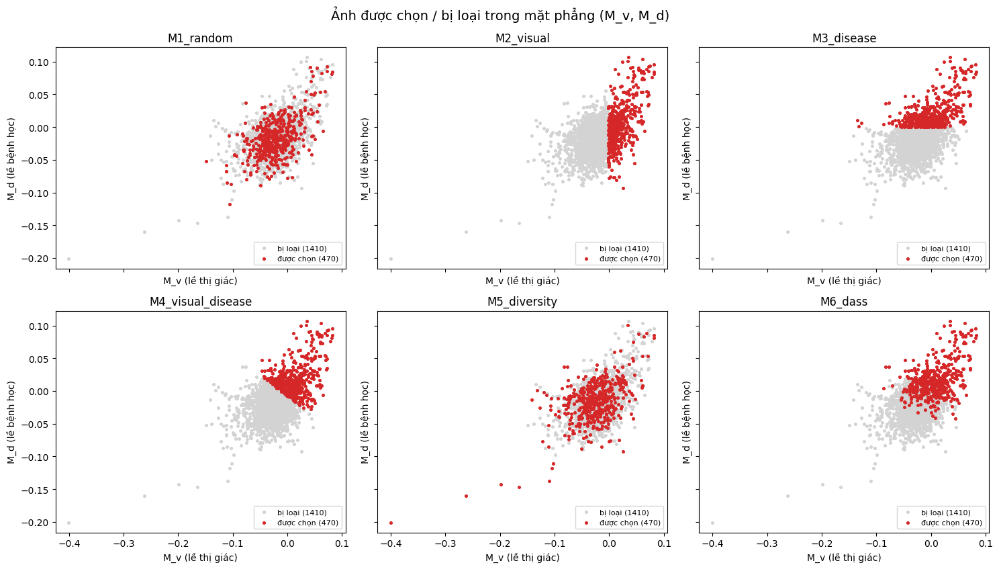

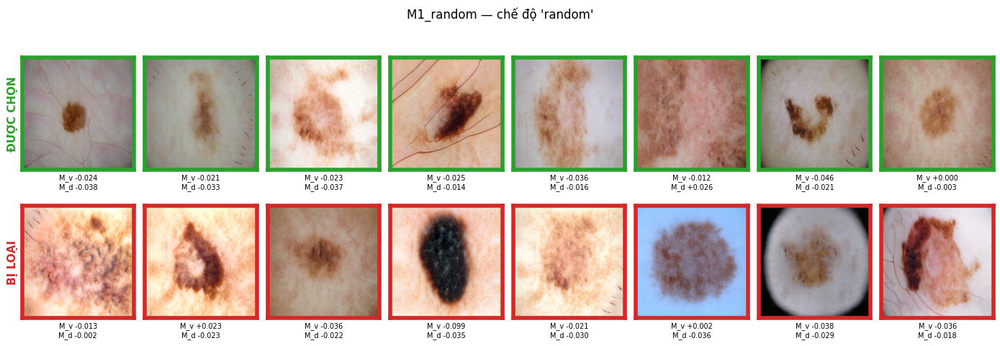

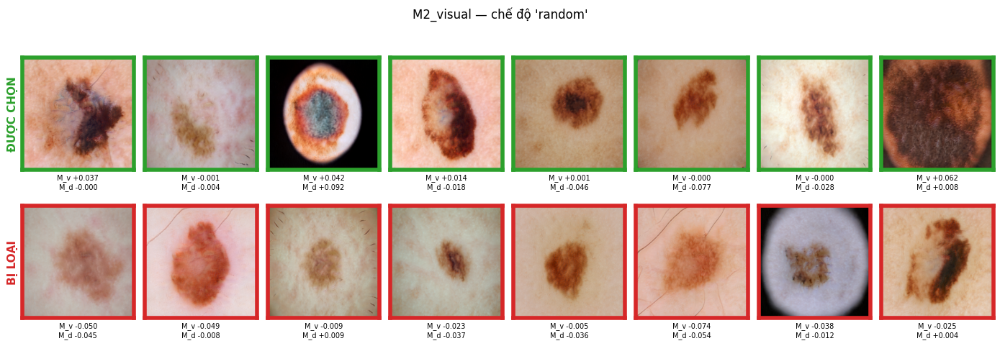

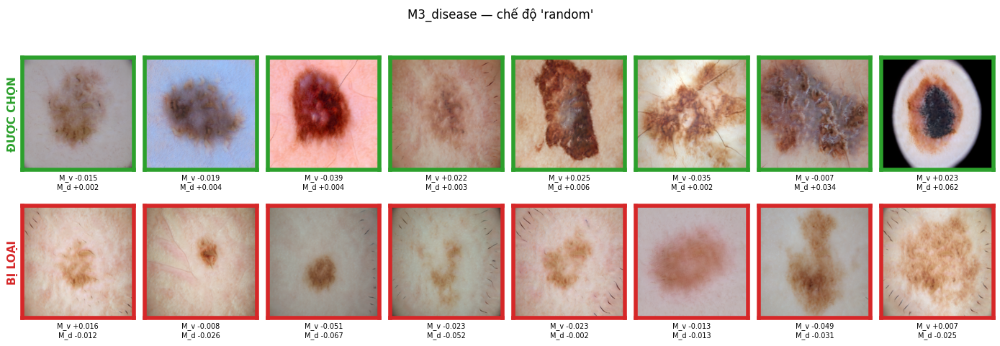

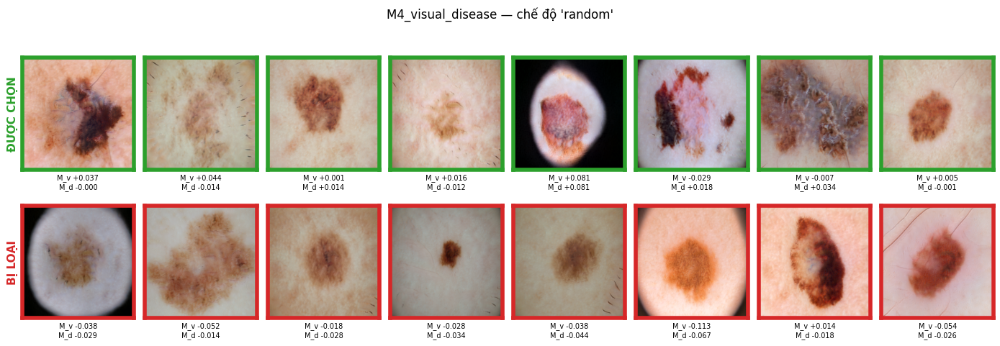

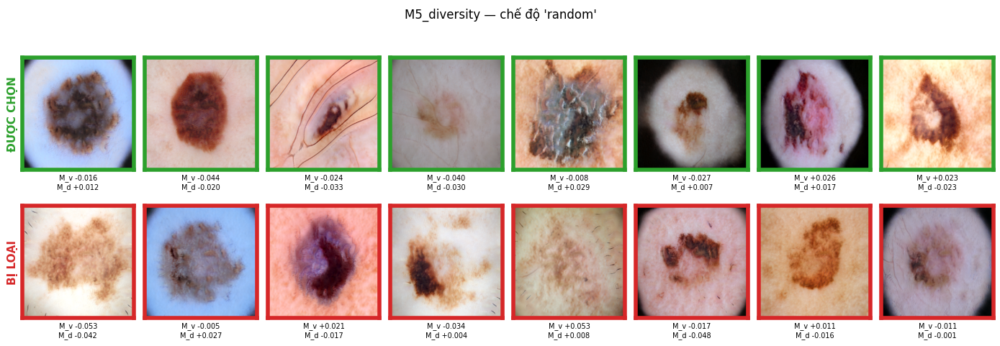

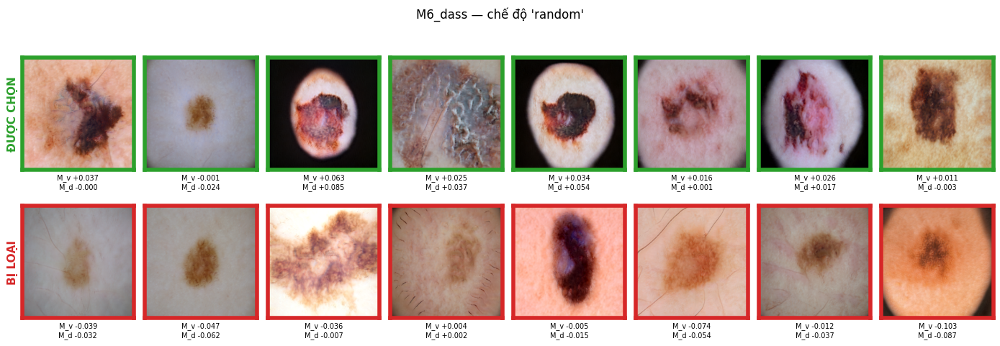

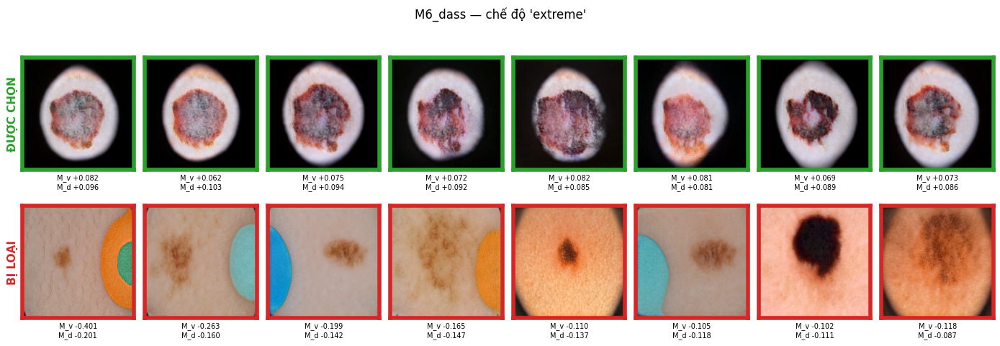

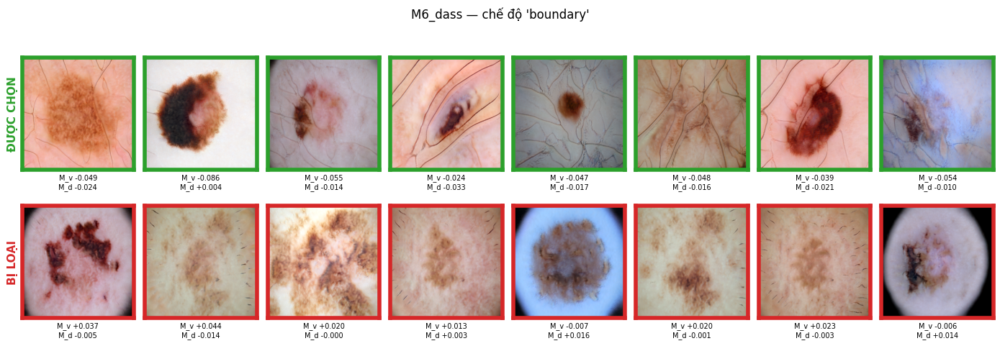

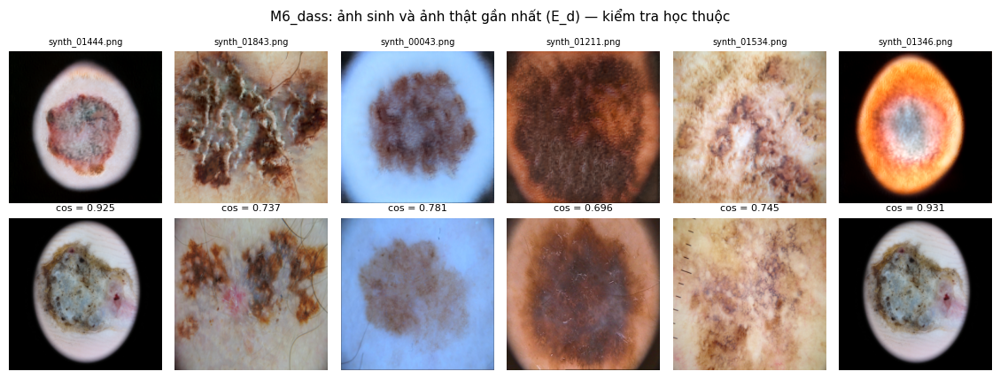

Đã lưu hình vào: /content/drive/MyDrive/Colab Notebooks/ColabData/ISBI2016_ISIC_Part3/results_v7/selection_figures


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

FIG_DIR = os.path.join(CFG.DRIVE_RESULTS_DIR, "selection_figures")
os.makedirs(FIG_DIR, exist_ok=True)
SYNTH_METHODS = [m for m, v in filtering_results.items() if v["sel_idx"]]


def plot_score_scatter():
    M_v, M_d = POOL_SCORES["M_v"], POOL_SCORES["M_d"]
    cols = 3
    rows = int(np.ceil(len(SYNTH_METHODS) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.3 * rows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, m in zip(axes, SYNTH_METHODS):
        sel = np.zeros(len(M_v), dtype=bool)
        sel[filtering_results[m]["sel_idx"]] = True
        ax.scatter(M_v[~sel], M_d[~sel], s=7, c="lightgray", label=f"bị loại ({(~sel).sum()})")
        ax.scatter(M_v[sel], M_d[sel], s=7, c="tab:red", label=f"được chọn ({sel.sum()})")
        ax.set_title(m)
        ax.set_xlabel("M_v (lề thị giác)")
        ax.set_ylabel("M_d (lề bệnh học)")
        ax.legend(fontsize=8, loc="lower right")
    for ax in axes[len(SYNTH_METHODS):]:
        ax.axis("off")
    fig.suptitle("Ảnh được chọn / bị loại trong mặt phẳng (M_v, M_d)", fontsize=14)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "scatter_Mv_Md.png"), dpi=120, bbox_inches="tight")
    plt.show()


def show_selected_vs_removed(method, n=8, mode="random", seed=0):
    """mode: 'random' | 'extreme' (chọn điểm cao nhất vs loại thấp nhất) | 'boundary' (sát ranh giới)."""
    sel = np.zeros(len(CANDIDATE_POOL), dtype=bool)
    sel[filtering_results[method]["sel_idx"]] = True
    sel_idx, rem_idx = np.where(sel)[0], np.where(~sel)[0]
    score = minmax(POOL_SCORES["M_v"]) * CFG.ALPHA + minmax(POOL_SCORES["M_d"]) * CFG.BETA
    rng = np.random.default_rng(seed)
    if mode == "random":
        a = rng.choice(sel_idx, min(n, len(sel_idx)), replace=False)
        b = rng.choice(rem_idx, min(n, len(rem_idx)), replace=False)
    elif mode == "extreme":
        a, b = sel_idx[np.argsort(-score[sel_idx])][:n], rem_idx[np.argsort(score[rem_idx])][:n]
    elif mode == "boundary":
        a, b = sel_idx[np.argsort(score[sel_idx])][:n], rem_idx[np.argsort(-score[rem_idx])][:n]
    else:
        raise ValueError(mode)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.75, 4.9))
    for row, (idxs, color, label) in enumerate([(a, "tab:green", "ĐƯỢC CHỌN"), (b, "tab:red", "BỊ LOẠI")]):
        for col in range(n):
            ax = axes[row, col]
            ax.set_xticks([])
            ax.set_yticks([])
            if col >= len(idxs):
                ax.axis("off")
                continue
            i = idxs[col]
            ax.imshow(Image.open(CANDIDATE_POOL[i]))
            for sp in ax.spines.values():
                sp.set_edgecolor(color)
                sp.set_linewidth(4)
            ax.set_xlabel(f"M_v {POOL_SCORES['M_v'][i]:+.3f}\nM_d {POOL_SCORES['M_d'][i]:+.3f}", fontsize=7)
        axes[row, 0].set_ylabel(label, fontsize=11, color=color, fontweight="bold")
    fig.suptitle(f"{method} — chế độ '{mode}'", fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"grid_{method}_{mode}.png"), dpi=120, bbox_inches="tight")
    plt.show()


def show_nearest_real(method, n=6):
    idx = filtering_results[method]["sel_idx"][:n]
    sims = Z_D_POOL[idx] @ Z_D_REAL[MINORITY].T          # cosine trong không gian E_d
    nn = sims.argmax(axis=1)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.9, 4.4))
    for col, (i, j) in enumerate(zip(idx, nn)):
        axes[0, col].imshow(Image.open(CANDIDATE_POOL[i]))
        axes[0, col].set_title(os.path.basename(CANDIDATE_POOL[i]), fontsize=7)
        axes[1, col].imshow(Image.open(REAL_TRAIN_PATHS[MINORITY][j]))
        axes[1, col].set_title(f"cos = {sims[col, j]:.3f}", fontsize=8)
        axes[0, col].axis("off")
        axes[1, col].axis("off")
    fig.suptitle(f"{method}: ảnh sinh và ảnh thật gần nhất (E_d) — kiểm tra học thuộc", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"nearest_real_{method}.png"), dpi=120, bbox_inches="tight")
    plt.show()


def separability_auc(emb_a, emb_b, seed=SEED):
    X = np.concatenate([emb_a, emb_b])
    y = np.r_[np.zeros(len(emb_a)), np.ones(len(emb_b))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    return float(roc_auc_score(y, p))


rows = [{"so_sanh": f"THAM CHIẾU: {MAJORITY} thật vs {MINORITY} thật (E_v)",
         "auc_5fold": separability_auc(Z_V_REAL[MAJORITY], Z_V_REAL[MINORITY])}]
for m in SYNTH_METHODS:
    rows.append({"so_sanh": f"{m}: thật vs sinh (E_v)",
                 "auc_5fold": separability_auc(Z_V_REAL[MINORITY], filtering_results[m]["emb_v"])})
shortcut_df = pd.DataFrame(rows)
shortcut_df.to_csv(os.path.join(CFG.DRIVE_RESULTS_DIR, "shortcut_check.csv"), index=False)
print(shortcut_df.round(4).to_string(index=False))

if CFG.SHOW_GRIDS:
    plot_score_scatter()
    for m in SYNTH_METHODS:
        show_selected_vs_removed(m, mode="random")
    show_selected_vs_removed("M6_dass", mode="extreme")
    show_selected_vs_removed("M6_dass", mode="boundary")
    show_nearest_real("M6_dass")
    print("Đã lưu hình vào:", FIG_DIR)

In [ ]:
for name in ["CLASS_BUDGET", "POOLS", "pools_for_k", "REAL_EMB", "greedy_dass_selection",
             "run_filtering_methods", "filtering_results_k", "POOL_INFO"]:
    print(f"{name:24s}", "OK" if name in globals() else "THIẾU")

CLASS_BUDGET             OK
POOLS                    OK
pools_for_k              OK
REAL_EMB                 OK
greedy_dass_selection    OK
run_filtering_methods    OK
filtering_results_k      OK
POOL_INFO                OK


## Bước 7d — Oversampling bằng phép biến đổi (hybrid augmentation của CosSIF)

CosSIF không chỉ dùng ảnh GAN: mỗi lớp còn được bù bằng ảnh **biến đổi** từ ảnh thật (xoay, lật, đổi khung,
dịch chuyển). Notebook sinh sẵn một pool ảnh biến đổi cho mỗi lớp (đủ cho trường hợp M0t cần bù toàn bộ),
các biến thể khác lấy phần đầu của pool đó.

Ảnh biến đổi **chỉ vào tập train**; val và test luôn 100% ảnh thật, chưa qua biến đổi.

Biến đổi benign:   0%|          | 0/1382 [00:00<?, ?it/s]

Biến đổi malignant:   0%|          | 0/1852 [00:00<?, ?it/s]

benign: 1382 ảnh biến đổi (dùng 346 cho M1–M6, 1382 cho M0t)
malignant: 1852 ảnh biến đổi (dùng 463 cho M1–M6, 1852 cho M0t)


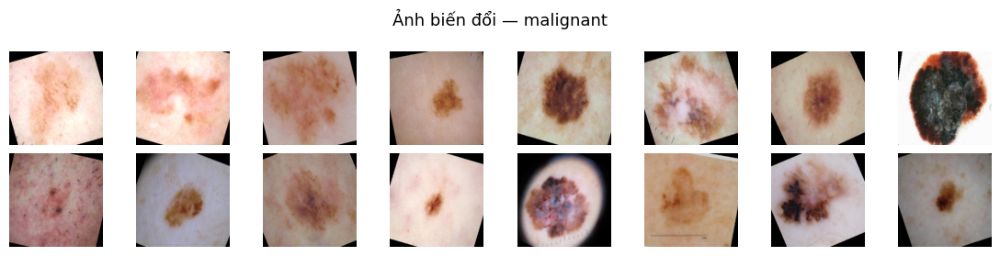

In [ ]:
def build_transformed_pool(cfg, split, seed=SEED):
    """Sinh pool ảnh biến đổi cho mỗi lớp (đủ để bù toàn bộ khoảng thiếu nếu cần)."""
    rng = np.random.default_rng(seed)
    pools = {}
    for label in cfg.CLASS_TO_IDX:
        out_dir = os.path.join(cfg.LOCAL_TRANSFORMED, label)
        os.makedirs(out_dir, exist_ok=True)
        need = CLASS_BUDGET[label]["gap"]
        existing = sorted(glob.glob(os.path.join(out_dir, "*.png")))
        if len(existing) >= need:
            pools[label] = existing[:need]
            print(f"  {label}: dùng lại {need} ảnh biến đổi có sẵn")
            continue
        srcs = [os.path.join(cfg.LOCAL_TRAIN_PP, label, f) for f in split[label]["train"]]
        paths = []
        for i in tqdm(range(need), desc=f"Biến đổi {label}"):
            img = Image.open(srcs[i % len(srcs)]).convert("RGB")
            if rng.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            if rng.random() < 0.5:
                img = img.transpose(Image.FLIP_TOP_BOTTOM)
            img = img.rotate(float(rng.uniform(-25, 25)), resample=Image.BILINEAR, fillcolor=None)
            # đổi khung (zoom/crop) và dịch chuyển nhẹ
            s = float(rng.uniform(0.85, 1.0))
            w = int(cfg.IMG_SIZE * s)
            x0 = int(rng.integers(0, cfg.IMG_SIZE - w + 1))
            y0 = int(rng.integers(0, cfg.IMG_SIZE - w + 1))
            img = img.crop((x0, y0, x0 + w, y0 + w)).resize((cfg.IMG_SIZE, cfg.IMG_SIZE), _BILINEAR)
            p = os.path.join(out_dir, f"trans_{i:05d}.png")
            img.save(p, format="PNG")
            paths.append(p)
        pools[label] = paths
    return pools


TRANSFORMED_POOL = build_transformed_pool(CFG, REAL_VAL_SPLIT)
for c in CFG.CLASS_TO_IDX:
    print(f"{c}: {len(TRANSFORMED_POOL[c])} ảnh biến đổi (dùng {CLASS_BUDGET[c]['transform']} cho M1–M6, "
          f"{CLASS_BUDGET[c]['gap']} cho M0t)")
if CFG.SHOW_GRIDS:
    plot_image_grid(TRANSFORMED_POOL["malignant"], "Ảnh biến đổi — malignant")

## Bước 8 — Ghép tập huấn luyện (tăng cường một chiều)

Mỗi biến thể: lớp đa số giữ nguyên ảnh thật; lớp thiểu số = ảnh thật + `N_SELECT` ảnh sinh đã chọn.
Val giữ nguyên 100% ảnh thật ở mọi biến thể.

In [ ]:
def assemble_dataset(cfg, tagged_id, info, split):
    out_dir = os.path.join(cfg.LOCAL_VARIANTS, tagged_id)
    shutil.rmtree(out_dir, ignore_errors=True)
    for s in ["train", "val"]:
        for c in cfg.CLASS_TO_IDX:
            os.makedirs(os.path.join(out_dir, s, c), exist_ok=True)
    for c in cfg.CLASS_TO_IDX:
        for s in ["train", "val"]:
            for f in split[c][s]:
                shutil.copy2(os.path.join(cfg.LOCAL_TRAIN_PP, c, f), os.path.join(out_dir, s, c, f))
    for i, src in enumerate(info["selected"]):
        shutil.copy2(src, os.path.join(out_dir, "train", MINORITY, f"synth_{i:05d}.png"))
    cnt = {s: {c: len(os.listdir(os.path.join(out_dir, s, c))) for c in cfg.CLASS_TO_IDX} for s in ["train", "val"]}
    print(f"  {tagged_id}: {cnt}")
    return out_dir


def prepare_variants(cfg, filtering_results):
    variants = {}
    for method_id, info in filtering_results.items():
        tagged_id = f"{method_id}_p{cfg.POOL_MULT:g}"
        variants[tagged_id] = {"dir": assemble_dataset(cfg, tagged_id, info, REAL_VAL_SPLIT),
                               "method": method_id,
                               "lam": f"v{cfg.LAMBDA_V:g}_d{cfg.LAMBDA_D:g}",
                               "feature_space": "Ev+Ed",
                               "class_weight": info["class_weight"]}
    return variants


variant_dirs_k = prepare_variants(CFG, filtering_results)


def assert_clean_eval_sets(cfg, variants):
    for tag, info in variants.items():
        for c in cfg.CLASS_TO_IDX:
            bad = [f for f in os.listdir(os.path.join(info["dir"], "val", c)) if f.startswith("synth_")]
            assert not bad, f"{tag}/val/{c}: có {len(bad)} ảnh sinh"
    for c in cfg.CLASS_TO_IDX:
        bad = [f for f in os.listdir(os.path.join(cfg.LOCAL_TEST_PP, c)) if f.startswith("synth_")]
        assert not bad, f"test/{c}: có {len(bad)} ảnh sinh"
    print("OK: val và test chỉ chứa ảnh thật |",
          {c: len(os.listdir(os.path.join(cfg.LOCAL_TEST_PP, c))) for c in cfg.CLASS_TO_IDX}, "ảnh test")


assert_clean_eval_sets(CFG, variant_dirs_k)

  M0_real_only_p4: {'train': {'benign': 618, 'malignant': 148}, 'val': {'benign': 109, 'malignant': 25}}
  M1_random_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
  M2_visual_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
  M3_disease_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
  M4_visual_disease_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
  M5_diversity_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
  M6_dass_p4: {'train': {'benign': 618, 'malignant': 618}, 'val': {'benign': 109, 'malignant': 25}}
OK: val và test chỉ chứa ảnh thật | {'benign': 304, 'malignant': 75} ảnh test


## Bước 9 (đặt trước) — Định nghĩa classifier, augmentation và quy trình train

> Các hàm dưới đây được định nghĩa sớm vì **Bước 5b (E_d)** dùng lại chúng. Việc huấn luyện các model M0–M6 vẫn diễn ra ở Bước 10a.

```
                TRAIN  (thật + biến đổi + sinh GAN)
                  │
                  ↓
             Classifier  (2 giai đoạn: head → fine-tune)
                  │
          ┌───────┴────────┐
          ↓                ↓
      VALIDATION          TEST
   (100% ảnh thật)     (không đụng tới
          │              trong lúc train)
          ↓
   val Macro Recall  =  (sensitivity + specificity) / 2  @ 0.5
          │
          ↓
   chọn best epoch  (EarlyStopping + ModelCheckpoint, mode=max)
          │
          ↓
      checkpoint  (.weights.h5, nạp lại sau khi train)
          │
          ↓
   dự đoán TEST  (một lần duy nhất, ngưỡng 0.5)
          │
          ↓
 ┌───────────────────────┐
 │ ROC-AUC               │
 │ PR-AUC                │
 │ Sensitivity           │
 │ Specificity           │
 │ G-mean                │
 │ Balanced Accuracy     │
 │ Macro-F1              │
 │ MCC                   │
 └───────────────────────┘
```

- **Val chỉ dùng để chọn epoch**, không dùng để dò ngưỡng, không dùng để báo cáo kết quả.
- **Test chỉ được chạm tới một lần**, sau khi checkpoint tốt nhất đã được nạp lại.
- Augmentation chỉ áp dụng cho tập train; val và test đọc ảnh nguyên bản.

In [ ]:
def make_augmenter(seed):
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical", seed=seed),
        layers.RandomRotation(0.5, fill_mode="reflect", seed=seed),
        layers.RandomZoom((-0.1, 0.1), fill_mode="reflect", seed=seed),
        layers.RandomBrightness(0.1, value_range=(0, 255), seed=seed),
        layers.RandomContrast(0.1, seed=seed),
    ], name="augment")


def build_dataset(data_dir, preprocess_fn, shuffle, augment=False, seed=SEED):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, labels="inferred", label_mode="binary", class_names=list(CFG.CLASS_TO_IDX),
        image_size=(CFG.CLF_SIZE, CFG.CLF_SIZE), batch_size=CFG.CLF_BATCH_SIZE,
        shuffle=shuffle, seed=seed, verbose=False)
    if augment:
        aug = make_augmenter(seed)
        ds = ds.map(lambda x, y: (tf.clip_by_value(aug(x, training=True), 0.0, 255.0), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


def _build(base, preprocess):
    inputs = tf.keras.Input(shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3))
    x = base(inputs, training=False)          # BatchNorm luôn ở chế độ inference khi fine-tune
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return tf.keras.Model(inputs, outputs), base, preprocess


def build_resnet50():
    base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet",
                                          input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, tf.keras.applications.resnet50.preprocess_input)


def build_densenet121():
    base = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet",
                                             input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, tf.keras.applications.densenet.preprocess_input)


def build_efficientnetv2b0():
    # include_preprocessing=True: model tự chuẩn hóa, input giữ [0, 255]
    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights="imagenet", include_preprocessing=True,
                                                  input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, lambda x: tf.cast(x, tf.float32))


MODEL_BUILDERS = {"ResNet50": build_resnet50, "DenseNet121": build_densenet121,
                  "EfficientNetV2B0": build_efficientnetv2b0}


# ===================== Mô hình dùng trong bài báo CosSIF (ConvNeXt, Swin Transformer, ViT) =====================
# ConvNeXt có sẵn trong keras.applications; ViT và Swin lấy từ KerasHub.
def build_convnext_tiny():
    base = tf.keras.applications.ConvNeXtTiny(include_top=False, weights="imagenet",
                                              input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, lambda x: tf.cast(x, tf.float32))   # ConvNeXt tự chuẩn hoá bên trong model


def _build_keras_hub(preset):
    """ViT / Swin từ KerasHub: preprocessor của preset tự resize + chuẩn hoá nên preprocess ở tf.data là identity."""
    import keras_hub
    model = keras_hub.models.ImageClassifier.from_preset(preset, num_classes=1, activation="sigmoid")
    return model, model.backbone, (lambda x: tf.cast(x, tf.float32))


def build_vit_base():
    return _build_keras_hub(CFG.VIT_PRESET)


def build_swin_tiny():
    return _build_keras_hub(CFG.SWIN_PRESET)


MODEL_BUILDERS.update({"ConvNeXtTiny": build_convnext_tiny,
                       "ViT-B16": build_vit_base,
                       "SwinT": build_swin_tiny})
print("Các model có thể train:", list(MODEL_BUILDERS))


Các model có thể train: ['ResNet50', 'DenseNet121', 'EfficientNetV2B0', 'ConvNeXtTiny', 'ViT-B16', 'SwinT']


In [ ]:
class MacroRecall(tf.keras.metrics.Metric):
    """Recall trung bình macro cho bài toán nhị phân = (sensitivity + specificity) / 2, tại ngưỡng 0.5.
    CosSIF dùng recall macro cao nhất làm tiêu chí chọn model trong quá trình train."""

    def __init__(self, threshold=0.5, name="macro_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.pos = tf.keras.metrics.Recall(thresholds=threshold, name="rec_pos")
        self.neg = tf.keras.metrics.Recall(thresholds=threshold, name="rec_neg")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        self.pos.update_state(y_true, y_pred, sample_weight)
        self.neg.update_state(1.0 - y_true, 1.0 - y_pred, sample_weight)   # recall của lớp âm = specificity

    def result(self):
        return (self.pos.result() + self.neg.result()) / 2.0

    def reset_state(self):
        self.pos.reset_state()
        self.neg.reset_state()


def compute_class_weight_from_dir(train_dir):
    n = {i: len(os.listdir(os.path.join(train_dir, c))) for c, i in CFG.CLASS_TO_IDX.items()}
    total = sum(n.values())
    return {i: total / (len(n) * cnt) for i, cnt in n.items()}


def train_classifier(model_name, tagged_id, variant, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model, base, preprocess = MODEL_BUILDERS[model_name]()
    train_dir, val_dir = os.path.join(variant["dir"], "train"), os.path.join(variant["dir"], "val")
    train_ds = build_dataset(train_dir, preprocess, shuffle=True, augment=True, seed=seed)
    val_ds = build_dataset(val_dir, preprocess, shuffle=False)
    class_weight = compute_class_weight_from_dir(train_dir) if variant["class_weight"] else None
    metrics = [tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
               MacroRecall(name="macro_recall")]
    monitor = CFG.MONITOR_METRIC        # mặc định "val_macro_recall" (như CosSIF); đổi sang "val_auc" nếu muốn

    # Giai đoạn 1: chỉ train head
    base.trainable = False
    model.compile(optimizer=tf.keras.optimizers.AdamW(CFG.CLF_HEAD_LR), loss="binary_crossentropy", metrics=metrics)
    model.fit(train_ds, validation_data=val_ds, epochs=CFG.CLF_HEAD_EPOCHS, class_weight=class_weight, verbose=2)

    # Giai đoạn 2: fine-tune toàn bộ, chọn epoch tốt nhất theo CFG.MONITOR_METRIC
    base.trainable = True
    model.compile(optimizer=tf.keras.optimizers.AdamW(CFG.CLF_FT_LR, weight_decay=1e-4),
                  loss="binary_crossentropy", metrics=metrics)
    ckpt = os.path.join(CFG.LOCAL_CLF_CKPT, f"{model_name}__{tagged_id}__s{seed}.weights.h5")
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor=monitor, mode="max", patience=CFG.EARLY_STOP_PATIENCE),
        tf.keras.callbacks.ModelCheckpoint(ckpt, monitor=monitor, mode="max",
                                           save_best_only=True, save_weights_only=True),
    ]
    hist = model.fit(train_ds, validation_data=val_ds, epochs=CFG.CLF_FT_EPOCHS,
                     class_weight=class_weight, callbacks=callbacks, verbose=2)
    model.load_weights(ckpt)                  # nạp lại epoch tốt nhất theo tiêu chí trên
    best_epoch = int(np.argmax(hist.history[monitor])) + 1
    print(f"  -> best fine-tune epoch = {best_epoch}, {monitor} = {max(hist.history[monitor]):.4f}, "
          f"val AUC = {hist.history['val_auc'][best_epoch - 1]:.4f}")
    return model, preprocess, best_epoch

## Bước 10 — Đánh giá



In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score,
                             matthews_corrcoef, average_precision_score, confusion_matrix, roc_curve)


def predict_dir(model, preprocess, data_dir):
    ds = build_dataset(data_dir, preprocess, shuffle=False)
    y_true = np.concatenate([y.numpy().ravel() for _, y in ds]).astype(int)
    y_prob = model.predict(ds, verbose=0).ravel()
    return y_true, y_prob


def binary_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "sensitivity": sensitivity,
            "specificity": specificity,
            "g_mean": float(np.sqrt(sensitivity * specificity)),   # trung bình nhân — chỉ số chuẩn cho dữ liệu mất cân bằng
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "mcc": matthews_corrcoef(y_true, y_pred)}


def run_experiments(cfg, model_name, variants, k, seeds=None):
    seeds = seeds or cfg.CLF_SEEDS
    for tagged_id, variant in variants.items():
        for seed in seeds:
            out = os.path.join(cfg.DRIVE_PRED_DIR, f"{model_name}__{tagged_id}__s{seed}.npz")
            if os.path.exists(out):
                print(f"[bỏ qua, đã có] {os.path.basename(out)}")
                continue
            print(f"\n=== {model_name} | {tagged_id} | seed {seed} ===")
            model, preprocess, best_epoch = train_classifier(model_name, tagged_id, variant, seed)
            y_val, p_val = predict_dir(model, preprocess, os.path.join(variant["dir"], "val"))
            y_test, p_test = predict_dir(model, preprocess, cfg.LOCAL_TEST_PP)
            np.savez(out, y_val=y_val, p_val=p_val, y_test=y_test, p_test=p_test,
                     model=model_name, method=variant["method"], k=k, seed=seed, best_epoch=best_epoch,
                     lam=variant.get("lam", "-"), feature_space=variant.get("feature_space", "imagenet"))
            print(f"  test ROC-AUC = {roc_auc_score(y_test, p_test):.4f} | đã lưu {os.path.basename(out)}")
            del model
            gc.collect()
            tf.keras.backend.clear_session()

### Bước 10a — Train từng model (mỗi cell chạy độc lập, dừng/chạy lại được)

In [ ]:
run_experiments(CFG, "EfficientNetV2B0", variant_dirs_k, CFG.POOL_MULT, seeds=[2026])


=== EfficientNetV2B0 | M0_real_only_p4 | seed 2026 ===
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
48/48 - 73s - 2s/step - auc: 0.5341 - loss: 0.7084 - macro_recall: 0.5246 - pr_auc: 0.2040 - val_auc: 0.7391 - val_loss: 0.5798 - val_macro_recall: 0.6853 - val_pr_auc: 0.3379
Epoch 2/5
48/48 - 2s - 43ms/step - auc: 0.6445 - loss: 0.6540 - macro_recall: 0.6004 - pr_auc: 0.2880 - val_auc: 0.7372 - val_loss: 0.5693 - val_macro_recall: 0.6486 - val_pr_auc: 0.3676
Epoch 3/5
48/48 - 2s - 47ms/step - auc: 0.7285 - loss: 0.6073 - macro_recall: 0.6535 - pr_auc: 0.3748 - val_auc: 0.7330 - val_loss: 0.5420 - val_macro_recall: 0.6561 - val_pr_auc: 0.3532
Epoch 4/5
48/48 - 2s - 45ms/step - auc: 0.7842 - loss: 0.5627 - macro_recall: 0.7064 - pr_auc: 0.4601 - val_auc: 0.7158 - val_loss: 0.5157 - val_macro_recall: 0.6837 - val_pr_auc: 0.3288
Epoch 5/5
48/48 - 2s - 44ms/step - auc: 0.7535 - loss: 0.5779 - macro_recall: 0.6925 - pr_auc: 0.4486 - val_auc: 0.7240 - val_loss: 0.5032 - val_m

In [66]:
run_experiments(CFG, "EfficientNetV2B0", variant_dirs_k, CFG.POOL_MULT, seeds=[2027])


=== EfficientNetV2B0 | M0_real_only_p4 | seed 2027 ===
Epoch 1/5
48/48 - 47s - 973ms/step - auc: 0.5925 - loss: 0.6838 - macro_recall: 0.5516 - pr_auc: 0.2572 - val_auc: 0.7154 - val_loss: 0.5466 - val_macro_recall: 0.6391 - val_pr_auc: 0.3417
Epoch 2/5
48/48 - 2s - 44ms/step - auc: 0.7093 - loss: 0.6136 - macro_recall: 0.6279 - pr_auc: 0.3777 - val_auc: 0.7272 - val_loss: 0.5192 - val_macro_recall: 0.6128 - val_pr_auc: 0.3974
Epoch 3/5
48/48 - 2s - 44ms/step - auc: 0.7380 - loss: 0.5945 - macro_recall: 0.6588 - pr_auc: 0.4094 - val_auc: 0.7310 - val_loss: 0.5133 - val_macro_recall: 0.6237 - val_pr_auc: 0.3712
Epoch 4/5
48/48 - 2s - 44ms/step - auc: 0.7316 - loss: 0.5947 - macro_recall: 0.6531 - pr_auc: 0.4012 - val_auc: 0.7466 - val_loss: 0.5034 - val_macro_recall: 0.6391 - val_pr_auc: 0.4034
Epoch 5/5
48/48 - 2s - 46ms/step - auc: 0.7619 - loss: 0.5731 - macro_recall: 0.6739 - pr_auc: 0.4472 - val_auc: 0.7393 - val_loss: 0.4989 - val_macro_recall: 0.6437 - val_pr_auc: 0.3814
Epoch 1

#### ResNet50

In [ ]:
CFG.MONITOR_METRIC = "val_macro_recall"     # hoặc "val_auc" nếu muốn tiêu chí cũ

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2026])

[bỏ qua, đã có] ResNet50__M0_real_only_k1.5__s2026.npz
[bỏ qua, đã có] ResNet50__M0t_real_transform_k1.5__s2026.npz
[bỏ qua, đã có] ResNet50__M1_unfiltered_k1.5__s2026.npz
[bỏ qua, đã có] ResNet50__M2_random_k1.5__s2026.npz
[bỏ qua, đã có] ResNet50__M3_s_same_only_k1.5__s2026.npz

=== ResNet50 | M4_cds_only_k1.5_lam1 | seed 2026 ===
Epoch 1/5
250/250 - 27s - 109ms/step - auc: 0.8378 - loss: 0.5008 - macro_recall: 0.7535 - pr_auc: 0.8349 - val_auc: 0.7257 - val_loss: 0.5023 - val_macro_recall: 0.6128 - val_pr_auc: 0.3828
Epoch 2/5
250/250 - 10s - 39ms/step - auc: 0.8984 - loss: 0.4035 - macro_recall: 0.8210 - pr_auc: 0.8937 - val_auc: 0.7466 - val_loss: 0.4705 - val_macro_recall: 0.6312 - val_pr_auc: 0.4457
Epoch 3/5
250/250 - 10s - 41ms/step - auc: 0.9062 - loss: 0.3887 - macro_recall: 0.8238 - pr_auc: 0.9056 - val_auc: 0.7539 - val_loss: 0.4744 - val_macro_recall: 0.6620 - val_pr_auc: 0.4314
Epoch 4/5
250/250 - 10s - 38ms/step - auc: 0.9127 - loss: 0.3739 - macro_recall: 0.8288 - pr_a

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2027])

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2028])

#### DenseNet121

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2026])

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2027])

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2028])

#### ConvNeXtTiny (mô hình dùng trong CosSIF)

In [ ]:
run_experiments(CFG, "ConvNeXtTiny", variant_dirs_k, CFG.K_RUN, seeds=[2026])

#### SwinT (mô hình dùng trong CosSIF)

In [ ]:
run_experiments(CFG, "SwinT", variant_dirs_k, CFG.K_RUN, seeds=[2026])

### Bước 10b — Gộp kết quả, thống kê và chất lượng ảnh sinh

Cell này đọc **mọi file dự đoán có trên Drive**, nên chạy được kể cả khi mới xong một phần model.

In [67]:
def load_all_runs(pred_dir):
    rows, probs = [], {}
    for path in sorted(glob.glob(os.path.join(pred_dir, "*.npz"))):
        d = np.load(path, allow_pickle=True)
        model, method, k, seed = str(d["model"]), str(d["method"]), float(d["k"]), int(d["seed"])
        y_val, p_val, y_test, p_test = d["y_val"], d["p_val"], d["y_test"], d["p_test"]
        row = {"model": model, "method": method, "k": k, "seed": seed, "best_epoch": int(d["best_epoch"]),
               "val_roc_auc": roc_auc_score(y_val, p_val),
               "roc_auc": roc_auc_score(y_test, p_test), "pr_auc": average_precision_score(y_test, p_test)}
        row.update(binary_metrics(y_test, p_test))   # ngưỡng 0.5
        rows.append(row)
        probs[(model, method, k, seed)] = (y_test, p_test)
    return pd.DataFrame(rows), probs


def mean_std_table(df, cols):
    g = df.groupby(["model", "method", "k"])[cols]
    mean, std = g.mean(), g.std().fillna(0)
    out = mean.copy().astype(object)
    for c in cols:
        out[c] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(mean[c], std[c])]
    out["n_seeds"] = g.size()
    return out.reset_index()


def paired_bootstrap_auc(y, p_a, p_b, n_boot, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.r_[rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]
        diffs[i] = roc_auc_score(y[idx], p_a[idx]) - roc_auc_score(y[idx], p_b[idx])
    obs = roc_auc_score(y, p_a) - roc_auc_score(y, p_b)
    p_value = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return obs, lo, hi, p_value


def compare_to_baseline(probs, baseline, n_boot):
    """So sánh AUC (xác suất trung bình qua các seed chung) của từng phương pháp với baseline."""
    rows = []
    for (model, k) in sorted({(m, k) for m, _, k, _ in probs}):
        def runs_of(method):
            items = {s: v for (m, me, kk, s), v in probs.items() if m == model and me == method and kk == k}
            return items
        base = runs_of(baseline)
        if not base:
            continue
        for method in sorted({me for m, me, kk, _ in probs if m == model and kk == k} - {baseline}):
            cur = runs_of(method)
            common = sorted(set(base) & set(cur))
            if not common:
                continue
            y = base[common[0]][0]
            assert all(np.array_equal(y, cur[s][0]) for s in common), "Thứ tự nhãn test không khớp"
            p_b = np.mean([base[s][1] for s in common], axis=0)
            p_a = np.mean([cur[s][1] for s in common], axis=0)
            obs, lo, hi, pv = paired_bootstrap_auc(y, p_a, p_b, n_boot)
            rows.append({"model": model, "k": k, "method": method, "vs": baseline, "n_seeds": len(common),
                         "delta_auc": obs, "ci95_low": lo, "ci95_high": hi, "p_value": pv})
    return pd.DataFrame(rows)


runs_df, run_probs = load_all_runs(CFG.DRIVE_PRED_DIR)
print(f"Đã đọc {len(runs_df)} lần chạy.")
runs_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/all_runs.csv", index=False)

key_cols = ["roc_auc", "pr_auc", "accuracy", "sensitivity", "specificity", "g_mean",
            "balanced_accuracy", "f1", "macro_f1", "mcc"]
summary = mean_std_table(runs_df, key_cols)
summary.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/summary_mean_std.csv", index=False)
pd.set_option("display.width", 250)
print("\n=== Kết quả (mean ± std qua các seed) — ngưỡng 0.5 ===")
print(summary.to_string(index=False))

cmp_df = compare_to_baseline(run_probs, CFG.BASELINE_METHOD, CFG.N_BOOTSTRAP)
if len(cmp_df):
    cmp_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/paired_bootstrap_vs_{CFG.BASELINE_METHOD}.csv", index=False)
    print(f"\n=== Paired bootstrap ΔAUC so với {CFG.BASELINE_METHOD} (xác suất trung bình qua seed) ===")
    print(cmp_df.round(4).to_string(index=False))

Đã đọc 14 lần chạy.

=== Kết quả (mean ± std qua các seed) — ngưỡng 0.5 ===
           model            method   k       roc_auc        pr_auc      accuracy   sensitivity   specificity        g_mean balanced_accuracy            f1      macro_f1           mcc  n_seeds
EfficientNetV2B0      M0_real_only 4.0 0.739 ± 0.036 0.467 ± 0.043 0.720 ± 0.056 0.607 ± 0.066 0.748 ± 0.086 0.672 ± 0.002     0.678 ± 0.010 0.464 ± 0.023 0.637 ± 0.036 0.307 ± 0.038        2
EfficientNetV2B0         M1_random 4.0 0.751 ± 0.038 0.503 ± 0.065 0.769 ± 0.065 0.473 ± 0.141 0.842 ± 0.116 0.624 ± 0.051     0.658 ± 0.013 0.447 ± 0.004 0.650 ± 0.024 0.318 ± 0.042        2
EfficientNetV2B0         M2_visual 4.0 0.768 ± 0.008 0.509 ± 0.029 0.811 ± 0.013 0.333 ± 0.113 0.929 ± 0.044 0.551 ± 0.082     0.631 ± 0.034 0.406 ± 0.067 0.646 ± 0.027 0.323 ± 0.017        2
EfficientNetV2B0        M3_disease 4.0 0.758 ± 0.005 0.506 ± 0.026 0.799 ± 0.022 0.413 ± 0.019 0.895 ± 0.033 0.608 ± 0.003     0.654 ± 0.007 0.450 ± 0.016 0

In [ ]:
def load_all_runs(pred_dir):
    rows, probs = [], {}
    for path in sorted(glob.glob(os.path.join(pred_dir, "*.npz"))):
        d = np.load(path, allow_pickle=True)
        model, method, k, seed = str(d["model"]), str(d["method"]), float(d["k"]), int(d["seed"])
        lam = str(d["lam"]) if "lam" in d.files else "-"          # file cũ không có lambda
        y_val, p_val, y_test, p_test = d["y_val"], d["p_val"], d["y_test"], d["p_test"]
        row = {"model": model, "method": method, "lam": lam, "k": k, "seed": seed,
               "best_epoch": int(d["best_epoch"]),
               "val_roc_auc": roc_auc_score(y_val, p_val),
               "roc_auc": roc_auc_score(y_test, p_test), "pr_auc": average_precision_score(y_test, p_test)}
        row.update(binary_metrics(y_test, p_test))   # ngưỡng 0.5
        rows.append(row)
        probs[(model, method, lam, k, seed)] = (y_test, p_test)
    return pd.DataFrame(rows), probs


def mean_std_table(df, cols):
    g = df.groupby(["model", "method", "lam", "k"])[cols]
    mean, std = g.mean(), g.std().fillna(0)
    out = mean.copy().astype(object)
    for c in cols:
        out[c] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(mean[c], std[c])]
    out["n_seeds"] = g.size()
    return out.reset_index()


def paired_bootstrap_auc(y, p_a, p_b, n_boot, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.r_[rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]
        diffs[i] = roc_auc_score(y[idx], p_a[idx]) - roc_auc_score(y[idx], p_b[idx])
    obs = roc_auc_score(y, p_a) - roc_auc_score(y, p_b)
    p_value = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return obs, lo, hi, p_value


def compare_to_baseline(probs, baseline, n_boot):
    """So sánh AUC (xác suất trung bình qua các seed chung) của từng (phương pháp, lambda) với baseline."""
    rows = []
    for (model, k) in sorted({(m, kk) for m, _, _, kk, _ in probs}):
        def runs_of(method, lam=None):
            return {s: v for (m, me, lm, kk, s), v in probs.items()
                    if m == model and me == method and kk == k and (lam is None or lm == lam)}
        base = runs_of(baseline)
        if not base:
            continue
        combos = sorted({(me, lm) for m, me, lm, kk, _ in probs if m == model and kk == k and me != baseline})
        for method, lam in combos:
            cur = runs_of(method, lam)
            common = sorted(set(base) & set(cur))
            if not common:
                continue
            y = base[common[0]][0]
            assert all(np.array_equal(y, cur[s][0]) for s in common), "Thứ tự nhãn test không khớp"
            p_b = np.mean([base[s][1] for s in common], axis=0)
            p_a = np.mean([cur[s][1] for s in common], axis=0)
            obs, lo, hi, pv = paired_bootstrap_auc(y, p_a, p_b, n_boot)
            rows.append({"model": model, "k": k, "method": method, "lam": lam, "vs": baseline,
                         "n_seeds": len(common), "delta_auc": obs, "ci95_low": lo,
                         "ci95_high": hi, "p_value": pv})
    return pd.DataFrame(rows)


runs_df, run_probs = load_all_runs(CFG.DRIVE_PRED_DIR)
print(f"Đã đọc {len(runs_df)} lần chạy.")
runs_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/all_runs.csv", index=False)

key_cols = ["roc_auc", "pr_auc", "accuracy", "sensitivity", "specificity", "g_mean",
            "balanced_accuracy", "f1", "macro_f1", "mcc"]
summary = mean_std_table(runs_df, key_cols)
summary.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/summary_mean_std.csv", index=False)
pd.set_option("display.width", 250)
print("\n=== Kết quả (mean ± std qua các seed) — ngưỡng 0.5 ===")
print(summary.to_string(index=False))

cmp_df = compare_to_baseline(run_probs, CFG.BASELINE_METHOD, CFG.N_BOOTSTRAP)
if len(cmp_df):
    cmp_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/paired_bootstrap_vs_{CFG.BASELINE_METHOD}.csv", index=False)
    print(f"\n=== Paired bootstrap ΔAUC so với {CFG.BASELINE_METHOD} (xác suất trung bình qua seed) ===")
    print(cmp_df.round(4).to_string(index=False))

Đã đọc 8 lần chạy.

=== Kết quả (mean ± std qua các seed) — ngưỡng 0.5 ===
   model             method lam   k       roc_auc        pr_auc      accuracy   sensitivity   specificity        g_mean balanced_accuracy            f1      macro_f1           mcc  n_seeds
ResNet50       M0_real_only   - 1.5 0.811 ± 0.000 0.556 ± 0.000 0.834 ± 0.000 0.493 ± 0.000 0.918 ± 0.000 0.673 ± 0.000     0.706 ± 0.000 0.540 ± 0.000 0.719 ± 0.000 0.443 ± 0.000        1
ResNet50 M0t_real_transform   - 1.5 0.792 ± 0.000 0.582 ± 0.000 0.826 ± 0.000 0.413 ± 0.000 0.928 ± 0.000 0.619 ± 0.000     0.670 ± 0.000 0.484 ± 0.000 0.690 ± 0.000 0.392 ± 0.000        1
ResNet50      M1_unfiltered   - 1.5 0.800 ± 0.000 0.577 ± 0.000 0.826 ± 0.000 0.467 ± 0.000 0.914 ± 0.000 0.653 ± 0.000     0.691 ± 0.000 0.515 ± 0.000 0.704 ± 0.000 0.413 ± 0.000        1
ResNet50          M2_random   - 1.5 0.796 ± 0.000 0.554 ± 0.000 0.828 ± 0.000 0.440 ± 0.000 0.924 ± 0.000 0.638 ± 0.000     0.682 ± 0.000 0.504 ± 0.000 0.700 ± 0.000 0.4

In [65]:
def compute_fid(real_emb, fake_emb):
    from scipy.linalg import sqrtm
    mu1, s1 = real_emb.mean(0), np.cov(real_emb, rowvar=False)
    mu2, s2 = fake_emb.mean(0), np.cov(fake_emb, rowvar=False)
    covmean = np.real(sqrtm(s1 @ s2))
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean))


def compute_diversity(emb):
    sim = cosine_similarity_matrix(emb, emb)
    n = sim.shape[0]
    return 1.0 - float((sim.sum() - np.trace(sim)) / (n * (n - 1)))


def compute_ssim(image_paths, n_pairs=200):
    rng = np.random.default_rng(SEED)
    load = lambda p: tf.cast(tf.io.decode_png(tf.io.read_file(p), channels=3), tf.float32) / 255.0
    scores = []
    for _ in range(n_pairs):
        i, j = rng.choice(len(image_paths), size=2, replace=False)
        scores.append(float(tf.image.ssim(load(image_paths[i]), load(image_paths[j]), max_val=1.0)))
    return float(np.mean(scores))


quality_rows = []
for method_id, info in filtering_results_k.items():
    if info["emb"] is None:
        continue
    quality_rows.append({
        "method": method_id, "k": CFG.K_RUN, "n": len(info["selected"]),
        "kid_effnet": kid_from_features(real_malignant_emb.astype(np.float64), info["emb"].astype(np.float64),
                                        num_subsets=CFG.KID_SUBSETS, seed=CFG.KID_SEED),
        "fid_effnet_tham_khao": compute_fid(real_malignant_emb, info["emb"]),
        "diversity": compute_diversity(info["emb"]),
        "ssim_noi_bo": compute_ssim(info["selected"]),
    })
quality_df = pd.DataFrame(quality_rows).merge(
    shortcut_df.assign(method=shortcut_df["so_sanh"].str.split(":").str[0])[["method", "auc_5fold"]]
    .rename(columns={"auc_5fold": "auc_that_vs_sinh"}), on="method", how="left")
quality_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/quality_k{CFG.K_RUN}.csv", index=False)
print(f"=== Chất lượng ảnh sinh (k={CFG.K_RUN}) — FID trên {n_train_malignant_real} ảnh thật chỉ để tham khảo ===")
print(quality_df.round(4).to_string(index=False))
print("\nĐã lưu toàn bộ kết quả vào:", CFG.DRIVE_RESULTS_DIR)

AttributeError: type object 'CFG' has no attribute 'K_RUN'